<h1 style="color:#1F618D; font-weight:bold;">
Pipeline for CMOS VOC Sensor Data
</h1>

<h1 style="color:#1F618D; font-weight:bold;">
Business and Data Understanding
</h1>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This notebook documents the early CRISP-DM phases for the OBSeRVeD VOC sensing project, focusing on a structured understanding of time-series sensor runs prior to modeling.
</p>

<h1 style="color:#1F618D; font-weight:bold;">
1. Business Understanding
</h1>

<h2 style="color:#1F618D; font-weight:bold; margin-left:10px;">
Context
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The dataset consists of continuous sensor responses to both single-gas and mixed-gas exposures under varying coatings, concentration schedules, and repeated experimental runs.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Unlike frame-based data, this modality is inherently temporal. The analytical focus is therefore on the evolution of the signal over time, including baseline behavior, exposure response, plateau regions, and recovery dynamics.
</p>

<h2 style="color:#1F618D; font-weight:bold; margin-left:10px;">
Project Goal
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The objective is to establish a reliable foundation for downstream modeling by clearly defining prediction objectives, run-level experimental structure, constraints required for leakage-safe evaluation, and preprocessing requirements for time-series learning.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This notebook focuses on understanding and design decisions; model training is handled in subsequent pipeline stages.
</p>

<h2 style="color:#1F618D; font-weight:bold; margin-left:10px;">
1.1 Prediction Objective
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7;">
The workflow follows a two-stage classification design.
</p>

<p style="font-size:17px; margin-left:45px; line-height:1.7;">
- Stage 1: classify each window as <b>single_gas</b> or <b>mixture</b><br>
- Stage 2: for samples identified as <b>single_gas</b>, classify <b>Toluene</b> vs <b>2-butanone</b>
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7;">
This hierarchical structure guides data preparation, feature design, and evaluation strategy.
</p>

<h2 style="color:#1F618D; font-weight:bold; margin-left:10px;">
1.2 CRISP-DM Position
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7;">
This notebook primarily covers:
</p>

<p style="font-size:17px; margin-left:45px; line-height:1.7;">
- Business Understanding<br>
- Data Understanding<br>
- Early Data Preparation design
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7;">
The main deliverables are a precise problem definition, a validated run-level data structure, and a justified preprocessing strategy for subsequent pipeline stages.
</p>

<h2 style="color:#1F618D; font-weight:bold; margin-left:10px;">
1.3 Success Criterion
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7;">
The primary success criterion is that model performance must generalize to <b>unseen runs</b>, not merely unseen windows from known runs.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7;">
Since windows extracted from the same run are inherently dependent, evaluation must preserve run boundaries. This principle is defined here and referenced throughout later stages of the pipeline.
</p>

<h2 style="color:#1F618D; font-weight:bold; margin-left:10px;">
1.4 Risks and Assumptions
</h2>

<p style="font-size:17px; margin-left:45px; line-height:1.7;">
- Limited runs per condition may increase sensitivity to data splits<br>
- Coating and concentration variations introduce structured variability<br>
- Run-level metadata must be preserved to maintain valid interpretation and evaluation
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7;">
<b>Assumption:</b> A run-aware pipeline, combined with explicit preprocessing and metadata retention, can mitigate these risks in downstream modeling.
</p>

<h2 style="color:#1B4F72; font-weight:bold; margin-left:10px;">
1.5 Scope of This Notebook
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7;">
This notebook focuses exclusively on time-series data. The previously analyzed frame-based <b>.dat</b> modality is intentionally excluded to ensure clarity and avoid mixing fundamentally different data representations.
</p>

<h2 style="color:#1B4F72; font-weight:bold; margin-left:10px;">
1.6 Phase Outcome
</h2>

<p style="font-size:17px; margin-left:45px; line-height:1.7;">
- a clearly defined prediction target<br>
- a verified run-level dataset structure<br>
- evidence-based insights into temporal signal behavior<br>
- a preprocessing design that directly supports feature engineering and modeling stages
</p>

<h1 style="color:#1B4F72; font-weight:bold;">
2. Data Understanding
</h1>

<h2 style="color:#1B4F72; font-weight:bold; margin-left:10px;">
2.1 Dataset Overview
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Each experimental run is represented by paired time and ADC signal files. The experimental context is encoded within the directory structure and includes key factors such as gas condition, concentration schedule, coating type, and run index.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The data is inherently temporal and must be interpreted as continuous response trajectories rather than independent static observations. As a result, the run—not the individual measurement point—serves as the fundamental unit of analysis throughout the pipeline.
</p>

<h2 style="color:#1B4F72; font-weight:bold; margin-left:10px;">
2.2 File and Metadata Discovery
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The repository is scanned recursively to construct a complete inventory of runs and to associate each run with its corresponding experimental metadata.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This step ensures that all runs include valid paired measurements and consistent labeling across experimental conditions. It also establishes the metadata structure required for grouped analysis, leakage-safe splitting, and downstream evaluation design.
</p>

In [1]:
# ===============================
# Core Libraries
# ===============================
import pandas as pd
import numpy as np
from pathlib import Path

# ===============================
# Visualization
# ===============================
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

# ===============================
# Statistics & Analysis
# ===============================

# ===============================
# Optional: Time Handling
# ===============================

# ===============================
# Warnings (clean notebook output)
# ===============================
import warnings
warnings.filterwarnings("ignore")

# ===============================
# Display Settings (for Jupyter)
# ===============================
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.max_rows", 20)

# ===============================
# Quick Check
# ===============================
print("Libraries loaded successfully ✅")

np.random.seed(42)

Libraries loaded successfully ✅


In [2]:
# Data Path Setup

# Set the main data root (relative path from notebook location)
DATA_PATH = Path("../data/raw/CMOS_addtional_datasets")
#DATA_PATH = Path("../../Tolouene/dataset")

# Check if path exists and print status
if DATA_PATH.exists() and DATA_PATH.is_dir():
    print(f"DATA_PATH exists: {DATA_PATH.resolve()}")
else:
    print(f"ERROR: DATA_PATH does not exist: {DATA_PATH.resolve()}")

# Ensure plots are rendered inline
%matplotlib inline

DATA_PATH exists: F:\DataOps_GroupProject\OBSERVED_CMOS_VOC_MLOPS\data\raw\CMOS_addtional_datasets


In [3]:
time_series_plotted_exps = set()
histogram_plotted_exps = set()
comparison_plotted_exps = set()

In [4]:
from pathlib import Path
import pandas as pd

folder_to_label = {
    'Mixing_LowHigh concentrastions': 'Mixing_LowHigh_concentrations',
    'Mixing_SAME CONCENTRASTIONS': 'Mixing_SAME_CONCENTRATIONS',
    'UV ink - 2-butanone': 'UV ink - 2-butanone',
    'UV ink-Toluene': 'UV ink-Toluene',
    'ZIF8 ink - 2-butanone': 'ZIF8 ink - 2-butanone',
    'ZIF8 Layer -Toluene': 'ZIF8 Layer - Toluene'
}

def discover_measurement_runs(data_path):
    supported_exts = {'.txt', '.csv', '.tsv'}
    collected_files = []

    for file in Path(data_path).rglob('*'):
        if not file.is_file():
            continue
        if file.suffix.lower() not in supported_exts:
            continue
        if 'explanation' in file.name.lower():
            continue

        experiment_folder = None
        experiment_label = None

        for parent in file.parents:
            if parent.name in folder_to_label:
                experiment_folder = parent.name
                experiment_label = folder_to_label[parent.name]
                break

        collected_files.append({
            'file_path': file,
            'file_name': file.name,
            'parent_folder': file.parent,
            'experiment_folder': experiment_folder if experiment_folder else 'Unknown',
            'experiment_name': experiment_label if experiment_label else 'Unknown',
            'file_type': file.suffix.lower()
        })

    files_df = pd.DataFrame(collected_files)

    if files_df.empty:
        print("No supported measurement files were found.")
        return pd.DataFrame()

    def classify_measurement_file(file_name):
        name = file_name.lower()
        if 'adc' in name:
            return 'adc'
        if 'time' in name:
            return 'time'
        return 'other'

    files_df['measurement_role'] = files_df['file_name'].apply(classify_measurement_file)

    runs = []

    for run_folder, group in files_df.groupby('parent_folder'):
        adc_files = group[group['measurement_role'] == 'adc']
        time_files = group[group['measurement_role'] == 'time']
        other_files = group[group['measurement_role'] == 'other']

        adc_path = adc_files.iloc[0]['file_path'] if len(adc_files) == 1 else None
        time_path = time_files.iloc[0]['file_path'] if len(time_files) == 1 else None

        experiment_folder = group['experiment_folder'].iloc[0]
        experiment_name = group['experiment_name'].iloc[0]

        run_folder_name = Path(run_folder).name
        repeat_index = int(run_folder_name) if run_folder_name.isdigit() else None

        runs.append({
            'run_folder': run_folder,
            'run_folder_name': run_folder_name,
            'experiment_folder': experiment_folder,
            'experiment_name': experiment_name,
            'repeat_index': repeat_index,
            'adc_file': adc_path,
            'time_file': time_path,
            'has_adc': adc_path is not None,
            'has_time': time_path is not None,
            'is_complete_run': adc_path is not None and time_path is not None,
            'extra_measurement_files': len(other_files)
        })

    runs_df = pd.DataFrame(runs).sort_values(
        by=['experiment_name', 'repeat_index', 'run_folder_name'],
        na_position='last'
    ).reset_index(drop=True)

    print("\nRun-level summary:")
    for exp_name, group in runs_df.groupby('experiment_name'):
        print(f"  {exp_name}: {len(group)} run(s), {group['is_complete_run'].sum()} complete")

    incomplete_runs = runs_df[~runs_df['is_complete_run']]
    if not incomplete_runs.empty:
        print(f"\nWarning: {len(incomplete_runs)} incomplete run(s) found.")

    unknown_runs = runs_df[runs_df['experiment_name'] == 'Unknown']
    if not unknown_runs.empty:
        print(f"Warning: {len(unknown_runs)} run(s) could not be matched to a known experiment folder.")

    return runs_df


run_summary = discover_measurement_runs(DATA_PATH)
run_summary.head()


Run-level summary:
  Mixing_LowHigh_concentrations: 2 run(s), 2 complete
  Mixing_SAME_CONCENTRATIONS: 6 run(s), 6 complete
  UV ink - 2-butanone: 2 run(s), 2 complete
  UV ink-Toluene: 2 run(s), 2 complete
  ZIF8 Layer - Toluene: 2 run(s), 2 complete
  ZIF8 ink - 2-butanone: 2 run(s), 2 complete


,run_folder,run_folder_name,experiment_folder,experiment_name,repeat_index,adc_file,time_file,has_adc,has_time,is_complete_run,extra_measurement_files
0,..\data\raw\CMOS_addtional_datasets\Mixing_Low...,UV ink-exposed to Toluene and 2 butanone,Mixing_LowHigh concentrastions,Mixing_LowHigh_concentrations,NaN,..\data\raw\CMOS_addtional_datasets\Mixing_Low...,..\data\raw\CMOS_addtional_datasets\Mixing_Low...,True,True,True,0
1,..\data\raw\CMOS_addtional_datasets\Mixing_Low...,ZIF 8 ink-exposed to Toluene and 2 butanone - ...,Mixing_LowHigh concentrastions,Mixing_LowHigh_concentrations,NaN,..\data\raw\CMOS_addtional_datasets\Mixing_Low...,..\data\raw\CMOS_addtional_datasets\Mixing_Low...,True,True,True,0
2,..\data\raw\CMOS_addtional_datasets\Mixing_SAM...,1,Mixing_SAME CONCENTRASTIONS,Mixing_SAME_CONCENTRATIONS,1.0,..\data\raw\CMOS_addtional_datasets\Mixing_SAM...,..\data\raw\CMOS_addtional_datasets\Mixing_SAM...,True,True,True,0
3,..\data\raw\CMOS_addtional_datasets\Mixing_SAM...,1,Mixing_SAME CONCENTRASTIONS,Mixing_SAME_CONCENTRATIONS,1.0,..\data\raw\CMOS_addtional_datasets\Mixing_SAM...,..\data\raw\CMOS_addtional_datasets\Mixing_SAM...,True,True,True,0
4,..\data\raw\CMOS_addtional_datasets\Mixing_SAM...,2,Mixing_SAME CONCENTRASTIONS,Mixing_SAME_CONCENTRATIONS,2.0,..\data\raw\CMOS_addtional_datasets\Mixing_SAM...,..\data\raw\CMOS_addtional_datasets\Mixing_SAM...,True,True,True,0


In [5]:
from pathlib import Path
import pandas as pd

def inspect_folder_hierarchy(data_path):
    folder_records = []

    for file in Path(data_path).rglob('*'):
        if file.is_file():
            relative_parts = file.relative_to(data_path).parts[:-1]  # exclude file name

            for level, folder_name in enumerate(relative_parts, start=1):
                folder_records.append({
                    'folder_name': folder_name,
                    'level': level
                })

    folders_df = pd.DataFrame(folder_records)

    if folders_df.empty:
        print("No folders found.")
        return pd.DataFrame()

    summary = (
        folders_df
        .groupby(['level', 'folder_name'])
        .size()
        .reset_index(name='count')
        .sort_values(['level', 'folder_name'])
        .reset_index(drop=True)
    )

    return summary


folder_summary = inspect_folder_hierarchy(DATA_PATH)
folder_summary

,level,folder_name,count
0,1,Mixing_LowHigh concentrastions,10
1,1,Mixing_SAME CONCENTRASTIONS,20
2,1,UV ink - 2-butanone,8
3,1,UV ink-Toluene,8
4,1,ZIF8 Layer -Toluene,8
5,1,ZIF8 ink - 2-butanone,8
6,2,1,12
7,2,2,12
8,2,UV ink-exposed to Toluene and 2 butanone,13
9,2,ZIF 8 ink-exposed to Toluene and 2 butanone - ...,12


<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Folder depth and naming inconsistencies require ancestor-based lookup and label mapping to recover stable experiment identities across runs.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The recovered inventory confirms six experimental groups, with an uneven distribution of runs across conditions. This indicates that while the dataset is structurally organized, it is not balanced at the run level.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Run-level imbalance should be explicitly considered when interpreting exploratory comparisons and when defining train-test partitions for downstream modeling.
</p>



<h2 style="color:#1B4F72; font-weight:bold; margin-left:10px;">
2.3 Data Loading and Parsing Strategy
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Runs are loaded using a robust parsing procedure that handles heterogeneous delimiters and validates consistency between paired time and ADC signal files.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Unparseable or incomplete runs are reported without interrupting the workflow, ensuring that the loading stage remains reproducible, auditable, and suitable for subsequent analysis.
</p>

In [6]:
import pandas as pd
from pathlib import Path

def load_vector_file(file_path):
    df = None

    for sep in [',', '\t', r'\s+']:
        try:
            if sep == r'\s+':
                temp_df = pd.read_csv(file_path, sep=sep, engine='python', header=None)
            else:
                temp_df = pd.read_csv(file_path, delimiter=sep, header=None)

            if temp_df.shape[0] >= 10:
                df = temp_df
                break
        except Exception:
            pass

    if df is None:
        print(f"[ERROR] Could not parse {file_path.name}")
        return None

    values = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna().reset_index(drop=True)

    if len(values) < 10 or values.nunique() < 3:
        print(f"[ERROR] Invalid data in {file_path.name}")
        return None

    return values


loaded_runs = {}
failed_runs = []

for _, row in run_summary.iterrows():
    run_folder = row['run_folder']
    adc_file = row['adc_file']
    time_file = row['time_file']

    if not row['is_complete_run']:
        failed_runs.append({
            'run_folder': str(run_folder),
            'reason': 'Incomplete run (missing ADC or time file)'
        })
        continue

    adc_values = load_vector_file(adc_file)
    time_values = load_vector_file(time_file)

    if adc_values is None or time_values is None:
        failed_runs.append({
            'run_folder': str(run_folder),
            'reason': 'Failed to parse ADC or time file'
        })
        continue

    min_len = min(len(adc_values), len(time_values))
    if min_len < 10:
        failed_runs.append({
            'run_folder': str(run_folder),
            'reason': 'Too few aligned samples after loading'
        })
        continue

    df = pd.DataFrame({
        'time': time_values.iloc[:min_len].reset_index(drop=True),
        'signal': adc_values.iloc[:min_len].reset_index(drop=True)
    })

    if df['signal'].nunique() < 3:
        failed_runs.append({
            'run_folder': str(run_folder),
            'reason': 'Signal variability too low'
        })
        continue

    loaded_runs[run_folder] = {
        'data': df,
        'experiment_name': row['experiment_name'],
        'experiment_folder': row['experiment_folder'],
        'repeat_index': row['repeat_index']
    }

print(f"\nSuccessfully loaded {len(loaded_runs)} runs out of {len(run_summary)} discovered.")

if failed_runs:
    print("\nFailed runs:")
    for item in failed_runs:
        print(f"  - {item['run_folder']} -> {item['reason']}")
else:
    print("\nNo failed runs.")


Successfully loaded 16 runs out of 16 discovered.

No failed runs.


In [8]:
# --- DATASET COVERAGE AND INTEGRITY CHECKS ---
from collections import Counter

# 1. Run Discovery Summary
print("\n=== Run Discovery Summary ===")
total_runs = len(run_summary)
print(f"Total measurement runs found: {total_runs}")

exp_counts = run_summary['experiment_name'].value_counts()
print("\nRuns per experiment:")
print(exp_counts)

# 2. Loading Summary
print("\n=== Loading Summary ===")
loaded_run_paths = set(str(run_path) for run_path in loaded_runs.keys())

print(f"Runs successfully loaded: {len(loaded_run_paths)}")
print(f"Runs failed to load: {len(failed_runs)}")

if failed_runs:
    print("\nFailed runs:")
    for item in failed_runs:
        print(f"  - {item['run_folder']} -> {item['reason']}")
else:
    print("No failed runs.")

# 3. Experiment Coverage
print("\n=== Experiment Coverage ===")
loaded_exp = [content['experiment_name'] for content in loaded_runs.values()]
loaded_exp_counts = Counter(loaded_exp)

print("Experiment | Discovered Runs | Loaded Runs")
for exp in sorted(exp_counts.index):
    print(f"{exp:30} | {exp_counts.get(exp, 0):15} | {loaded_exp_counts.get(exp, 0)}")

# 4. Data Integrity Check
print("\n=== Data Integrity Check ===")
missing_exps = [exp for exp in exp_counts.index if loaded_exp_counts.get(exp, 0) == 0]

if missing_exps:
    print("Experiments with ZERO valid loaded runs:")
    for exp in missing_exps:
        print(f"  - {exp}")
else:
    print("All experiment groups have at least one valid loaded run.")

partial_exps = [
    exp for exp in exp_counts.index
    if 0 < loaded_exp_counts.get(exp, 0) < exp_counts.get(exp, 0)
]

if partial_exps:
    print("\nExperiments with partial loading coverage:")
    for exp in partial_exps:
        print(f"  - {exp}: loaded {loaded_exp_counts.get(exp, 0)} / discovered {exp_counts.get(exp, 0)}")
else:
    print("No partial loading issues detected.")

# 5. Final Summary
print("\n=== FINAL SUMMARY ===")

data_issues_detected = False

if failed_runs:
    data_issues_detected = True
if missing_exps:
    data_issues_detected = True
if partial_exps:
    data_issues_detected = True

if data_issues_detected:
    print("Data integrity issues detected:")
    if failed_runs:
        print(f"- {len(failed_runs)} runs failed to load.")
    if missing_exps:
        print(f"- {len(missing_exps)} experiment groups have zero valid loaded runs.")
    if partial_exps:
        print(f"- {len(partial_exps)} experiment groups have only partial loading coverage.")
else:
    print("The dataset has been successfully discovered and loaded, and no structural data issues were found.")


=== Run Discovery Summary ===
Total measurement runs found: 16

Runs per experiment:
experiment_name
Mixing_SAME_CONCENTRATIONS       6
Mixing_LowHigh_concentrations    2
UV ink - 2-butanone              2
UV ink-Toluene                   2
ZIF8 Layer - Toluene             2
ZIF8 ink - 2-butanone            2
Name: count, dtype: int64

=== Loading Summary ===
Runs successfully loaded: 16
Runs failed to load: 0
No failed runs.

=== Experiment Coverage ===
Experiment | Discovered Runs | Loaded Runs
Mixing_LowHigh_concentrations  |               2 | 2
Mixing_SAME_CONCENTRATIONS     |               6 | 6
UV ink - 2-butanone            |               2 | 2
UV ink-Toluene                 |               2 | 2
ZIF8 Layer - Toluene           |               2 | 2
ZIF8 ink - 2-butanone          |               2 | 2

=== Data Integrity Check ===
All experiment groups have at least one valid loaded run.
No partial loading issues detected.

=== FINAL SUMMARY ===
The dataset has been successfull

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
All 16 discovered runs were successfully loaded, with no failed runs and no partially covered experiment groups.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This confirms that the dataset inventory is complete and internally consistent at the run level across the six identified experiment groups. However, the number of runs remains uneven across conditions.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The dataset is structurally ready for exploratory analysis and downstream preprocessing. Run-level imbalance should still be considered when comparing experimental groups and defining train-test partitions.
</p>

<h2 style="color:#1B4F72; font-weight:bold; margin-left:10px;">
2.4 Initial Structural Inspection
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
A subset of loaded runs is inspected to verify structural consistency, including schema validity, data types, and alignment between time and ADC signal arrays.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This step validates that the parsed outputs are structurally consistent and suitable for downstream exploratory time-series analysis.
</p>

In [9]:
for i, (run_path, content) in enumerate(loaded_runs.items()):
    df = content['data']
    experiment_name = content['experiment_name']
    experiment_folder = content['experiment_folder']
    repeat_index = content['repeat_index']

    print(f"Experiment Group: {experiment_name}")
    print(f"Experiment Folder: {experiment_folder}")
    print(f"Run Path: {run_path}")
    print(f"Repeat Index: {repeat_index}")
    print("Shape:", df.shape)
    print("Columns:", df.columns.tolist())
    print("Dtypes:")
    print(df.dtypes)
    print("Time column: time | Signal column: signal")
    print(df.head())
    print("-" * 80)

    if i >= 2:  # show only first 3 runs
        break

Experiment Group: Mixing_LowHigh_concentrations
Experiment Folder: Mixing_LowHigh concentrastions
Run Path: ..\data\raw\CMOS_addtional_datasets\Mixing_LowHigh concentrastions\UV ink-exposed to Toluene and 2 butanone
Repeat Index: nan
Shape: (7748, 2)
Columns: ['time', 'signal']
Dtypes:
time      float64
signal    float64
dtype: object
Time column: time | Signal column: signal
    time   signal
0  0.000  0.25106
1  0.633  0.21908
2  1.183  0.11263
3  1.864  0.01792
4  2.966  0.00921
--------------------------------------------------------------------------------
Experiment Group: Mixing_LowHigh_concentrations
Experiment Folder: Mixing_LowHigh concentrastions
Run Path: ..\data\raw\CMOS_addtional_datasets\Mixing_LowHigh concentrastions\ZIF 8 ink-exposed to Toluene and 2 butanone - Copy
Repeat Index: nan
Shape: (7748, 2)
Columns: ['time', 'signal']
Dtypes:
time      float64
signal    float64
dtype: object
Time column: time | Signal column: signal
    time   signal
0  0.000  0.44860
1  0.63

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
All inspected runs exhibit a consistent two-column structure (<b>time</b> and <b>signal</b>) with aligned lengths and valid numeric data types. However, some runs contain missing values in metadata fields such as <b>repeat_index</b>.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The parsing pipeline successfully standardizes the temporal data structure, ensuring compatibility for time-series analysis. The presence of missing metadata values suggests that certain experimental annotations are incomplete or inconsistently defined across runs.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The dataset is structurally ready for visualization, segmentation, and feature extraction. However, metadata fields such as <b>repeat_index</b> may require cleaning or reconstruction before being used in grouping, stratification, or evaluation design.
</p>

<h1 style="color:#1B4F72; font-weight:bold;">
3. Exploratory Data Analysis (EDA)
</h1>

<h2 style="color:#1B4F72; font-weight:bold; margin-left:10px;">
3.1 Time-Series Profiles
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Representative runs are visualized to examine the temporal response of the sensor signals across experiment groups, focusing on baseline, response, and recovery behavior.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
This step provides a concise view of signal dynamics and supports the design of segmentation and feature extraction in later stages.
</p>

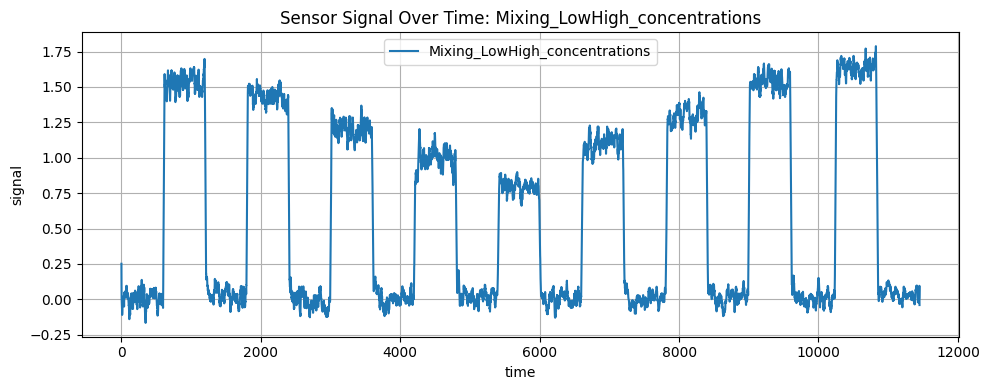

Mixing_LowHigh_concentrations | Run: UV ink-exposed to Toluene and 2 butanone | Repeat: nan
Experiment Folder: Mixing_LowHigh concentrastions
Baseline: 0.04 | Peak: 1.79 | Recovery: 0.01
Interpretation: Relative increase from baseline
--------------------------------------------------------------------------------


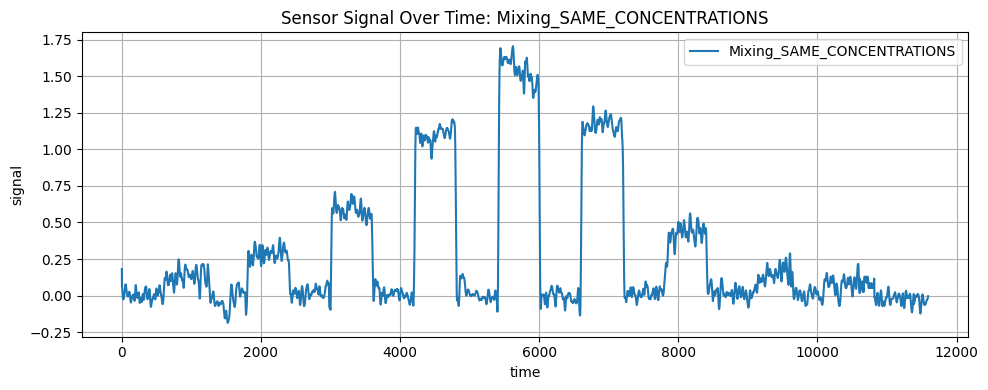

Mixing_SAME_CONCENTRATIONS | Run: 1 | Repeat: 1.0
Experiment Folder: Mixing_SAME CONCENTRASTIONS
Baseline: 0.05 | Peak: 1.71 | Recovery: -0.02
Interpretation: Relative increase from baseline
--------------------------------------------------------------------------------


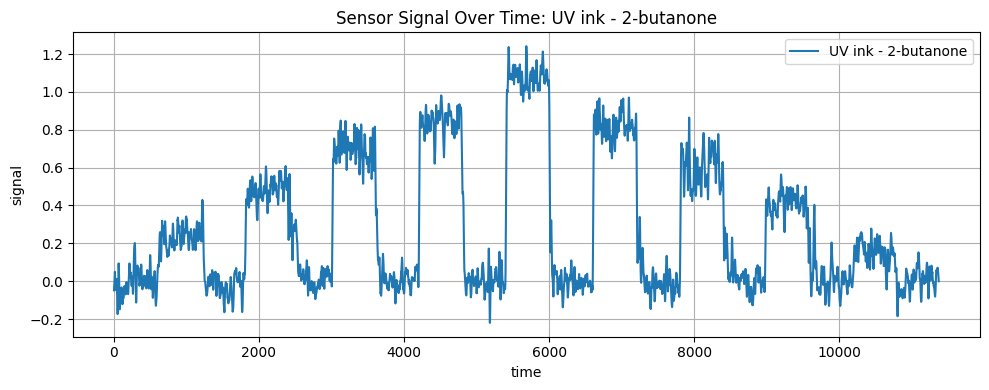

UV ink - 2-butanone | Run: 1 | Repeat: 1.0
Experiment Folder: UV ink - 2-butanone
Baseline: 0.00 | Peak: 1.24 | Recovery: 0.03
Interpretation: Relative increase from baseline
--------------------------------------------------------------------------------


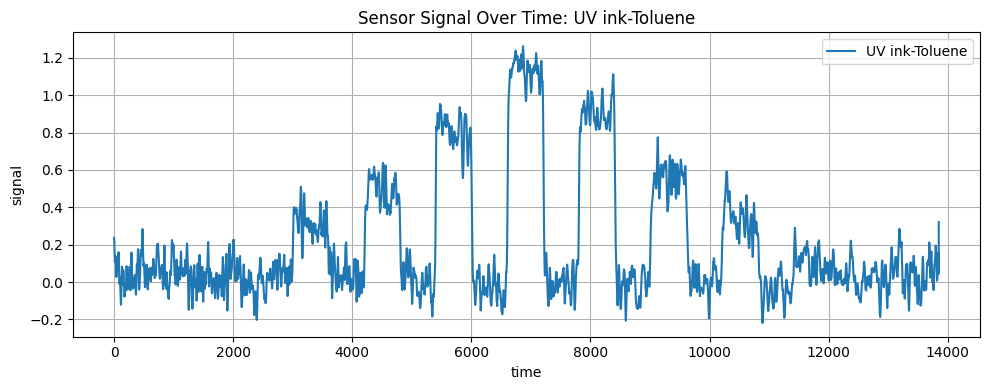

UV ink-Toluene | Run: 1 | Repeat: 1.0
Experiment Folder: UV ink-Toluene
Baseline: 0.16 | Peak: 1.26 | Recovery: 0.14
Interpretation: Relative increase from baseline
--------------------------------------------------------------------------------


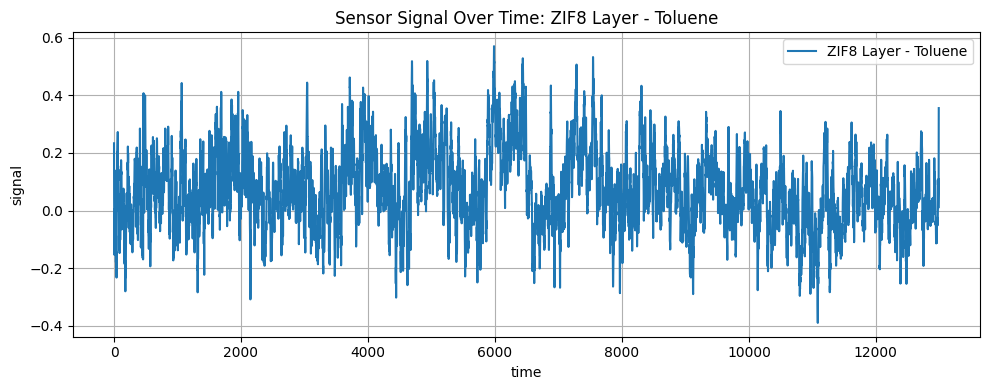

ZIF8 Layer - Toluene | Run: 1 | Repeat: 1.0
Experiment Folder: ZIF8 Layer -Toluene
Baseline: 0.00 | Peak: 0.57 | Recovery: 0.06
Interpretation: Relative increase from baseline
--------------------------------------------------------------------------------


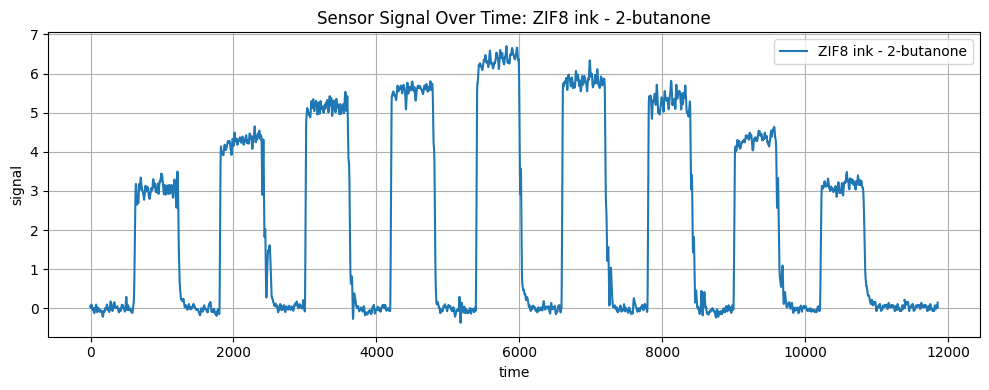

ZIF8 ink - 2-butanone | Run: 1 | Repeat: 1.0
Experiment Folder: ZIF8 ink - 2-butanone
Baseline: 0.04 | Peak: 6.70 | Recovery: 0.06
Interpretation: Relative increase from baseline
--------------------------------------------------------------------------------

Time-series plot counts per experiment:
  Mixing_LowHigh_concentrations: 1 run(s) plotted
  Mixing_SAME_CONCENTRATIONS: 1 run(s) plotted
  UV ink - 2-butanone: 1 run(s) plotted
  UV ink-Toluene: 1 run(s) plotted
  ZIF8 Layer - Toluene: 1 run(s) plotted
  ZIF8 ink - 2-butanone: 1 run(s) plotted


In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# Plot one representative run from each experiment group
def plot_and_interpret_time_series(loaded_runs, run_summary):
    plotted_exps = set()
    plot_counts = {}
    summary_rows = []

    expected_experiments = set(run_summary['experiment_name'].unique())

    for run_path, content in loaded_runs.items():
        df = content['data']
        exp = content['experiment_name']
        exp_folder = content['experiment_folder']
        repeat_index = content['repeat_index']

        # Plot only one representative run per experiment group
        if exp in plotted_exps:
            continue

        # Safety checks
        if df is None or df.empty:
            print(f"[WARN] Empty data for {run_path}")
            continue

        if 'time' not in df.columns or 'signal' not in df.columns:
            print(f"[WARN] Missing required columns in {run_path}")
            continue

        # Plot
        plt.figure(figsize=(10, 4))
        plt.plot(df['time'], df['signal'], label=exp)
        plt.xlabel('time')
        plt.ylabel('signal')
        plt.title(f"Sensor Signal Over Time: {exp}")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Simple descriptive statistics
        baseline = df['signal'].iloc[:10].mean()
        exposure_peak = df['signal'].max()
        recovery = df['signal'].iloc[-10:].mean()

        # Heuristic interpretation
        if baseline != 0 and exposure_peak > baseline * 1.2:
            interpretation = "Relative increase from baseline"
        elif baseline != 0 and exposure_peak < baseline * 0.8:
            interpretation = "Relative decrease from baseline"
        else:
            interpretation = "Limited variation / relatively stable signal"

        # Short text output
        print(f"{exp} | Run: {run_path.name} | Repeat: {repeat_index}")
        print(f"Experiment Folder: {exp_folder}")
        print(f"Baseline: {baseline:.2f} | Peak: {exposure_peak:.2f} | Recovery: {recovery:.2f}")
        print(f"Interpretation: {interpretation}")
        print("-" * 80)

        # Save summary
        summary_rows.append({
            'experiment_name': exp,
            'run_name': run_path.name,
            'repeat_index': repeat_index,
            'baseline': baseline,
            'peak': exposure_peak,
            'recovery': recovery,
            'interpretation': interpretation
        })

        plotted_exps.add(exp)
        plot_counts[exp] = plot_counts.get(exp, 0) + 1

        # Stop after one representative run per experiment group
        if plotted_exps == expected_experiments:
            break

    print("\nTime-series plot counts per experiment:")
    for exp in sorted(plot_counts):
        print(f"  {exp}: {plot_counts[exp]} run(s) plotted")

    summary_df = pd.DataFrame(summary_rows)

    return plotted_exps, plot_counts, summary_df


# Ensure variables are always defined
time_series_plotted_exps = set()
time_series_plot_counts = {}
time_series_summary_df = pd.DataFrame()

try:
    time_series_plotted_exps, time_series_plot_counts, time_series_summary_df = plot_and_interpret_time_series(
        loaded_runs, run_summary
    )
except Exception as e:
    print(f"[ERROR] Time-series plotting failed: {e}")

In [ ]:
time_series_summary_df

,experiment_name,file_name,baseline,peak,recovery,interpretation
0,ZIF8 Layer - Toluene,dataset1-ADC.txt,8.980100,13849.84700,13844.865900,Relative increase from baseline
1,ZIF8 ink - 2-butanone,dataset1-ADC.txt,0.038478,6.70134,0.058143,Relative increase from baseline
2,UV ink-Toluene,dataset1-ADC.txt,0.164970,1.26248,0.136943,Relative increase from baseline
3,UV ink - 2-butanone,dataset1-ADC.txt,0.000426,1.24157,0.031957,Relative increase from baseline
4,Mixing_SAME_CONCENTRATIONS,dataset1-ADC.txt,0.022710,5.29505,0.052860,Relative increase from baseline
5,Mixing_LowHigh_concentrations,dataset1-ADC.txt,0.038069,1.78820,0.010709,Relative increase from baseline


<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
All experiment groups exhibit clear step-like temporal response patterns, characterized by repeated transitions between baseline and elevated signal levels. Distinct phases of baseline, exposure, plateau, and recovery are consistently observable across runs.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
However, the amplitude and clarity of these responses vary significantly across experiments. For example, <b>ZIF8 ink - 2-butanone</b> shows strong high-amplitude responses, while <b>ZIF8 Layer - Toluene</b> exhibits lower signal-to-noise ratio with more irregular fluctuations. Mixed-gas conditions display intermediate behavior with overlapping response patterns.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The consistent step-like structure confirms that the sensor responses are driven by controlled exposure cycles, making temporal segmentation into baseline, response, and recovery phases feasible.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Variations in amplitude and noise levels across experiment groups indicate that both gas type and coating configuration significantly influence sensor sensitivity and response dynamics. This suggests that discriminative information is encoded not only in signal magnitude but also in temporal behavior.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The observed temporal structure supports the use of window-based segmentation aligned with exposure cycles for downstream modeling. Feature extraction should incorporate both amplitude-based metrics (e.g., peak response) and temporal characteristics (e.g., rise time, recovery behavior, variability).
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Differences in signal strength and noise levels across experiment groups also suggest that normalization and noise-reduction strategies may be necessary to ensure robust model performance.
</p>

<h2 style="color:#1B4F72; font-weight:bold; margin-left:10px;">
3.2 Stationarity Assessment
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Stationarity is assessed by comparing segment-wise statistics within representative runs, focusing on changes in mean and variability across time.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The objective is to identify where non-stationarity occurs and how it relates to the temporal response structure.
</p>

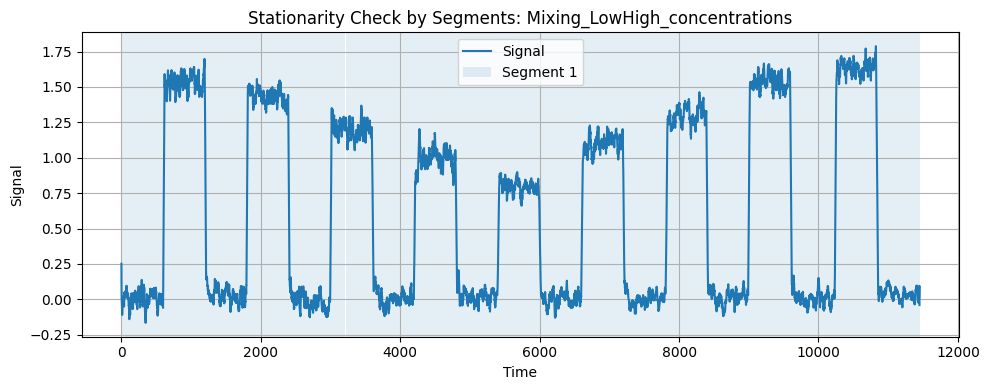

Experiment Group: Mixing_LowHigh_concentrations | Run: UV ink-exposed to Toluene and 2 butanone | Repeat: nan
  Segment 1: mean=0.63, std=0.71
  Segment 2: mean=0.56, std=0.50
  Segment 3: mean=0.65, std=0.73
  Mean range across segments: 0.08
  Std range across segments: 0.23
  Interpretation: The mean changes noticeably across segments, suggesting non-stationary behavior.
  The variability changes across segments, further suggesting non-stationary behavior.
--------------------------------------------------------------------------------


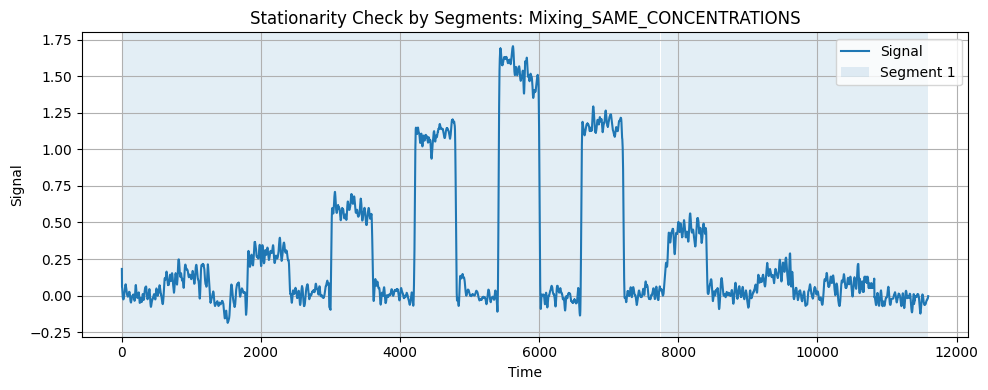

Experiment Group: Mixing_SAME_CONCENTRATIONS | Run: 1 | Repeat: 1.0
  Segment 1: mean=0.16, std=0.21
  Segment 2: mean=0.57, std=0.64
  Segment 3: mean=0.10, std=0.16
  Mean range across segments: 0.47
  Std range across segments: 0.48
  Interpretation: The mean changes noticeably across segments, suggesting non-stationary behavior.
  The variability changes across segments, further suggesting non-stationary behavior.
--------------------------------------------------------------------------------


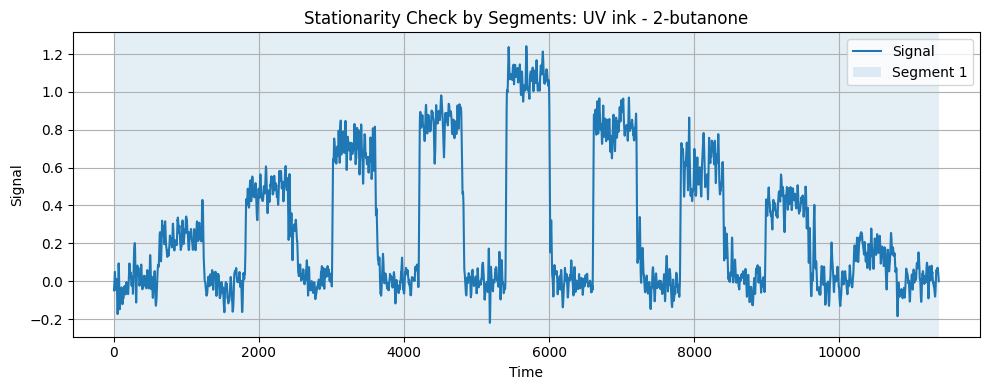

Experiment Group: UV ink - 2-butanone | Run: 1 | Repeat: 1.0
  Segment 1: mean=0.24, std=0.28
  Segment 2: mean=0.43, std=0.46
  Segment 3: mean=0.19, std=0.24
  Mean range across segments: 0.24
  Std range across segments: 0.22
  Interpretation: The mean changes noticeably across segments, suggesting non-stationary behavior.
  The variability changes across segments, further suggesting non-stationary behavior.
--------------------------------------------------------------------------------


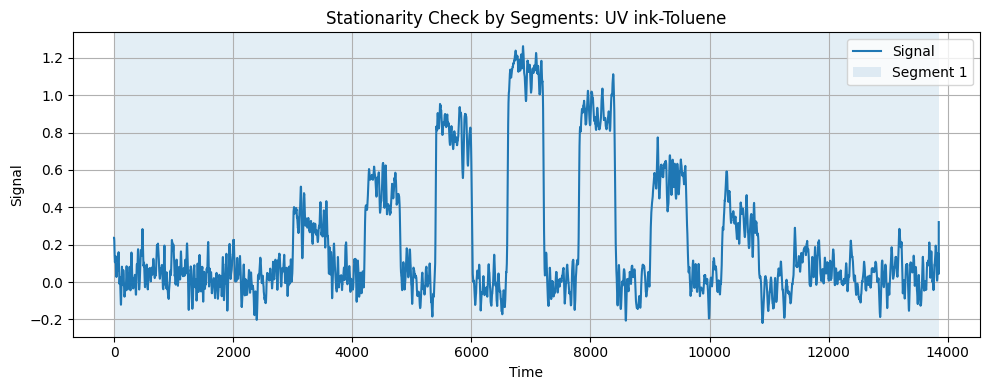

Experiment Group: UV ink-Toluene | Run: 1 | Repeat: 1.0
  Segment 1: mean=0.08, std=0.12
  Segment 2: mean=0.41, std=0.45
  Segment 3: mean=0.12, std=0.20
  Mean range across segments: 0.33
  Std range across segments: 0.32
  Interpretation: The mean changes noticeably across segments, suggesting non-stationary behavior.
  The variability changes across segments, further suggesting non-stationary behavior.
--------------------------------------------------------------------------------


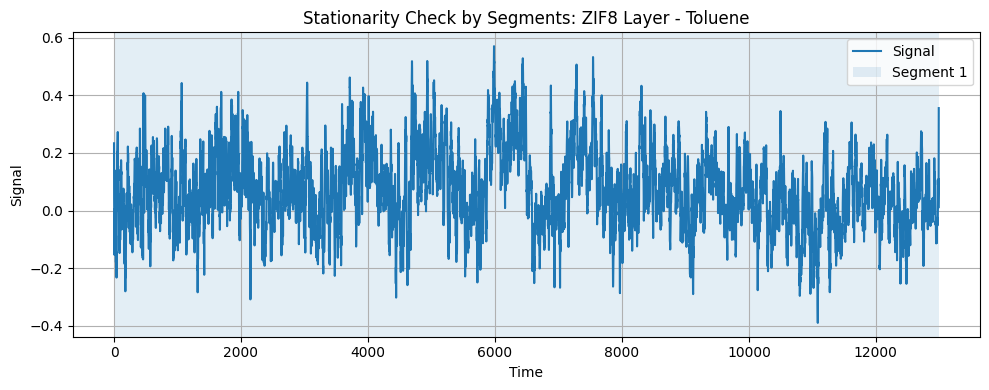

Experiment Group: ZIF8 Layer - Toluene | Run: 1 | Repeat: 1.0
  Segment 1: mean=0.07, std=0.12
  Segment 2: mean=0.12, std=0.15
  Segment 3: mean=0.04, std=0.12
  Mean range across segments: 0.08
  Std range across segments: 0.04
  Interpretation: The mean changes noticeably across segments, suggesting non-stationary behavior.
  The variability changes across segments, further suggesting non-stationary behavior.
--------------------------------------------------------------------------------


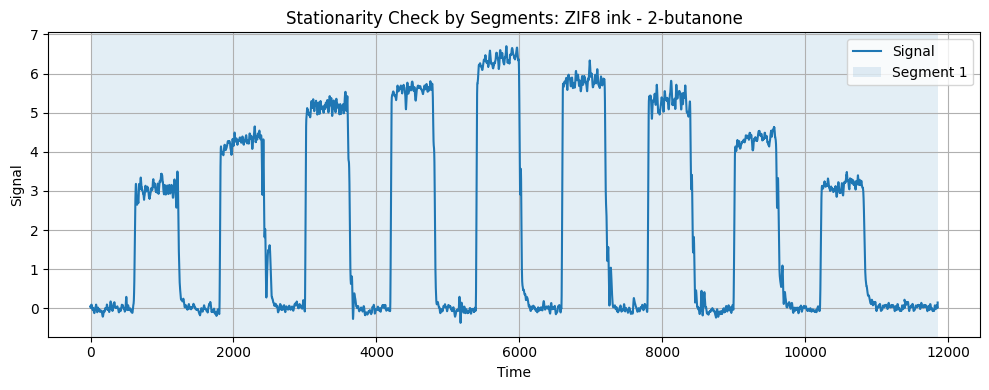

Experiment Group: ZIF8 ink - 2-butanone | Run: 1 | Repeat: 1.0
  Segment 1: mean=1.99, std=2.13
  Segment 2: mean=2.71, std=2.90
  Segment 3: mean=1.96, std=2.15
  Mean range across segments: 0.75
  Std range across segments: 0.76
  Interpretation: The mean changes noticeably across segments, suggesting non-stationary behavior.
  The variability changes across segments, further suggesting non-stationary behavior.
--------------------------------------------------------------------------------


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

def assess_stationarity_by_segments(loaded_runs, run_summary, num_segments=3):
    plotted_exps = set()
    stationarity_rows = []

    expected_experiments = set(run_summary['experiment_name'].unique())

    for run_path, content in loaded_runs.items():
        df = content['data'].copy()
        exp = content['experiment_name']
        repeat_index = content['repeat_index']

        if exp in plotted_exps:
            continue

        if df is None or df.empty or len(df) < num_segments * 10:
            continue

        if 'time' not in df.columns or 'signal' not in df.columns:
            print(f"[WARN] Missing required columns in {run_path}")
            continue

        # Split into contiguous segments
        segment_size = len(df) // num_segments
        segment_stats = []

        plt.figure(figsize=(10, 4))
        plt.plot(df['time'], df['signal'], label='Signal')

        for i in range(num_segments):
            start = i * segment_size
            end = (i + 1) * segment_size if i < num_segments - 1 else len(df)
            segment = df.iloc[start:end]

            seg_mean = segment['signal'].mean()
            seg_std = segment['signal'].std()

            segment_stats.append({
                'segment': i + 1,
                'mean': seg_mean,
                'std': seg_std
            })

            stationarity_rows.append({
                'experiment_name': exp,
                'run_name': run_path.name,
                'repeat_index': repeat_index,
                'segment': i + 1,
                'segment_mean': seg_mean,
                'segment_std': seg_std
            })

            # Highlight segment
            plt.axvspan(
                df['time'].iloc[start],
                df['time'].iloc[end - 1],
                alpha=0.12,
                label=f'Segment {i+1}' if i == 0 else None
            )

        plt.title(f'Stationarity Check by Segments: {exp}')
        plt.xlabel('Time')
        plt.ylabel('Signal')
        plt.legend()
        plt.tight_layout()
        plt.show()

        print(f"Experiment Group: {exp} | Run: {run_path.name} | Repeat: {repeat_index}")
        for stat in segment_stats:
            print(f"  Segment {stat['segment']}: mean={stat['mean']:.2f}, std={stat['std']:.2f}")

        means = [s['mean'] for s in segment_stats]
        stds = [s['std'] for s in segment_stats]

        mean_range = max(means) - min(means)
        std_range = max(stds) - min(stds)

        print(f"  Mean range across segments: {mean_range:.2f}")
        print(f"  Std range across segments: {std_range:.2f}")

        valid_means = [abs(m) for m in means if pd.notna(m)]
        valid_stds = [abs(s) for s in stds if pd.notna(s)]

        if valid_means and mean_range < 0.1 * max(valid_means):
            print("  Interpretation: The mean remains relatively stable across segments.")
        else:
            print("  Interpretation: The mean changes noticeably across segments, suggesting non-stationary behavior.")

        if valid_stds and std_range < 0.1 * max(valid_stds):
            print("  The variability remains relatively stable across segments.")
        else:
            print("  The variability changes across segments, further suggesting non-stationary behavior.")

        print("-" * 80)

        plotted_exps.add(exp)

        if plotted_exps == expected_experiments:
            break

    stationarity_df = pd.DataFrame(stationarity_rows)
    return plotted_exps, stationarity_df


stationarity_plotted_exps, stationarity_summary_df = assess_stationarity_by_segments(
    loaded_runs, run_summary, num_segments=3
)

In [ ]:
stationarity_summary_df

,experiment_name,file_name,segment,segment_mean,segment_std
0,ZIF8 Layer - Toluene,dataset1-ADC.txt,1,1917.750414,1106.312509
1,ZIF8 Layer - Toluene,dataset1-ADC.txt,2,6194.669892,1408.316564
2,ZIF8 Layer - Toluene,dataset1-ADC.txt,3,11339.183422,1522.407241
3,ZIF8 ink - 2-butanone,dataset1-ADC.txt,1,1.992880,2.133741
4,ZIF8 ink - 2-butanone,dataset1-ADC.txt,2,2.712287,2.895618
5,ZIF8 ink - 2-butanone,dataset1-ADC.txt,3,1.959189,2.148042
6,UV ink-Toluene,dataset1-ADC.txt,1,0.078382,0.124647
7,UV ink-Toluene,dataset1-ADC.txt,2,0.409879,0.448401
8,UV ink-Toluene,dataset1-ADC.txt,3,0.123720,0.203122
9,UV ink - 2-butanone,dataset1-ADC.txt,1,0.239922,0.278828


<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Segment-wise statistics show clear variation in both mean and standard deviation across time within each run. These changes align with transitions between baseline and exposure phases, resulting in distinct statistical regimes within the same signal.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The magnitude of variation differs across experiment groups, with stronger signals (e.g., ZIF8 ink - 2-butanone) showing larger shifts, while lower-amplitude signals exhibit smaller but still noticeable changes.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The signal is inherently non-stationary, driven by controlled exposure cycles that introduce systematic changes in both level and variability. Each segment corresponds to a different physical state of the sensor (baseline, exposure, recovery), rather than a single stable process.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Modeling approaches should account for non-stationarity explicitly. This supports the use of window-based or segment-based feature extraction rather than global statistics. Features capturing local behavior (e.g., segment-level mean, variance, or transitions) are more appropriate than assumptions of global stationarity.
</p>

<h2 style="color:#1B4F72; font-weight:bold; margin-left:10px;">
3.3 Distribution and Signal Behavior
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Signal distributions are examined to characterize value spread, dominant ranges, and the presence of multiple operating regimes within each experiment group.
</p>

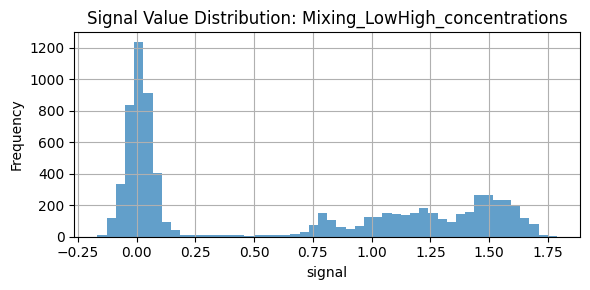

Mixing_LowHigh_concentrations | Run: UV ink-exposed to Toluene and 2 butanone | Repeat: nan
Experiment Folder: Mixing_LowHigh concentrastions
Mean: 0.61 | Std: 0.66 | Min: -0.17 | Max: 1.79
Interpretation: Relatively high variability. Presence of high-value peaks. Presence of low-value dips.
--------------------------------------------------------------------------------


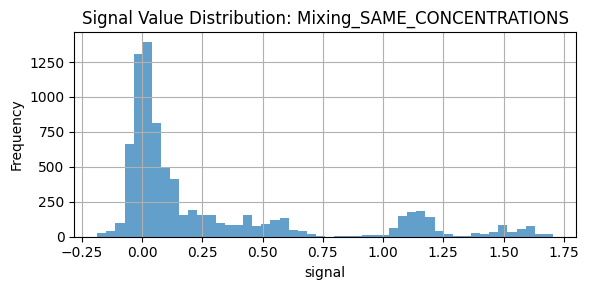

Mixing_SAME_CONCENTRATIONS | Run: 1 | Repeat: 1.0
Experiment Folder: Mixing_SAME CONCENTRASTIONS
Mean: 0.28 | Std: 0.45 | Min: -0.19 | Max: 1.71
Interpretation: Relatively high variability. Presence of high-value peaks. Presence of low-value dips.
--------------------------------------------------------------------------------


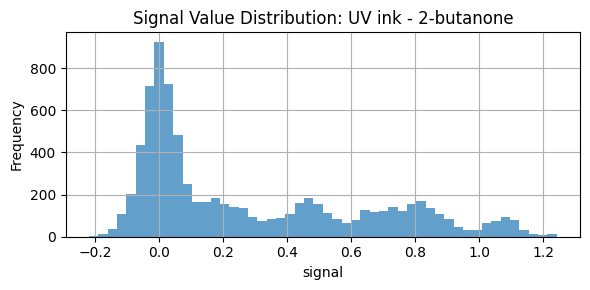

UV ink - 2-butanone | Run: 1 | Repeat: 1.0
Experiment Folder: UV ink - 2-butanone
Mean: 0.28 | Std: 0.36 | Min: -0.22 | Max: 1.24
Interpretation: Relatively high variability. Presence of high-value peaks. Presence of low-value dips.
--------------------------------------------------------------------------------


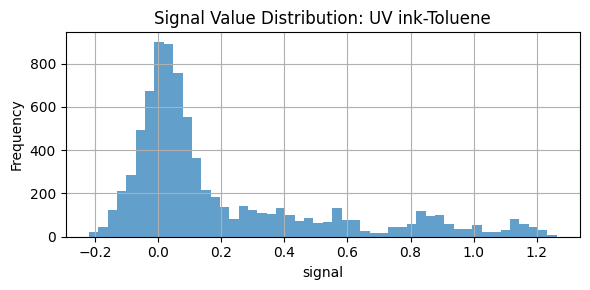

UV ink-Toluene | Run: 1 | Repeat: 1.0
Experiment Folder: UV ink-Toluene
Mean: 0.20 | Std: 0.33 | Min: -0.22 | Max: 1.26
Interpretation: Relatively high variability. Presence of high-value peaks. Presence of low-value dips.
--------------------------------------------------------------------------------


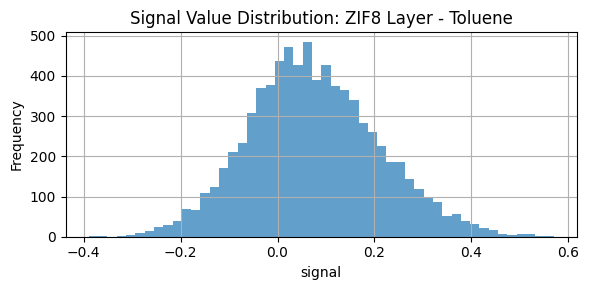

ZIF8 Layer - Toluene | Run: 1 | Repeat: 1.0
Experiment Folder: ZIF8 Layer -Toluene
Mean: 0.08 | Std: 0.13 | Min: -0.39 | Max: 0.57
Interpretation: Relatively high variability. Presence of high-value peaks. Presence of low-value dips.
--------------------------------------------------------------------------------


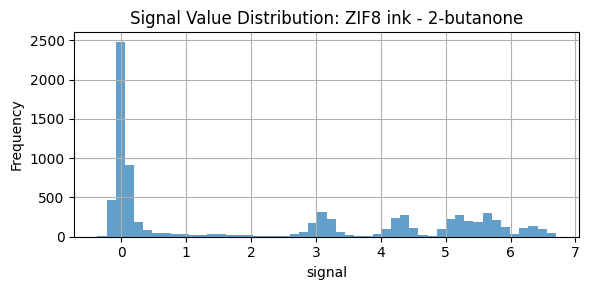

ZIF8 ink - 2-butanone | Run: 1 | Repeat: 1.0
Experiment Folder: ZIF8 ink - 2-butanone
Mean: 2.22 | Std: 2.44 | Min: -0.37 | Max: 6.70
Interpretation: Relatively high variability. Presence of high-value peaks. Presence of low-value dips.
--------------------------------------------------------------------------------

Histogram plot counts per experiment:
  Mixing_LowHigh_concentrations: 1 run(s) plotted
  Mixing_SAME_CONCENTRATIONS: 1 run(s) plotted
  UV ink - 2-butanone: 1 run(s) plotted
  UV ink-Toluene: 1 run(s) plotted
  ZIF8 Layer - Toluene: 1 run(s) plotted
  ZIF8 ink - 2-butanone: 1 run(s) plotted


In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Plot one representative histogram from each experiment group
def plot_and_interpret_histograms(loaded_runs, run_summary):
    plotted_exps = set()
    plot_counts = {}
    summary_rows = []

    expected_experiments = set(run_summary['experiment_name'].unique())

    for run_path, content in loaded_runs.items():
        df = content['data']
        exp = content['experiment_name']
        exp_folder = content['experiment_folder']
        repeat_index = content['repeat_index']

        # Plot only one representative run per experiment group
        if exp in plotted_exps:
            continue

        # Safety checks
        if df is None or df.empty:
            print(f"[WARN] Empty data for {run_path}")
            continue

        if 'signal' not in df.columns:
            print(f"[WARN] Missing signal column in {run_path}")
            continue

        signal_values = df['signal'].dropna()

        if len(signal_values) < 10:
            print(f"[WARN] Too few signal values in {run_path}")
            continue

        # Plot histogram
        plt.figure(figsize=(6, 3))
        plt.hist(signal_values, bins=50, alpha=0.7)
        plt.xlabel('signal')
        plt.ylabel('Frequency')
        plt.title(f'Signal Value Distribution: {exp}')
        plt.tight_layout()
        plt.show()

        # Descriptive statistics
        mean_val = signal_values.mean()
        std_val = signal_values.std()
        min_val = signal_values.min()
        max_val = signal_values.max()

        # Heuristic interpretation
        if mean_val != 0 and std_val > 0.1 * abs(mean_val):
            variability_note = "Relatively high variability"
        else:
            variability_note = "Relatively stable distribution"

        range_note = ""
        if mean_val != 0 and max_val > mean_val * 1.5:
            range_note += "Presence of high-value peaks. "
        if mean_val != 0 and min_val < mean_val * 0.5:
            range_note += "Presence of low-value dips."

        if range_note.strip() == "":
            range_note = "No strong extreme values observed."

        print(f"{exp} | Run: {run_path.name} | Repeat: {repeat_index}")
        print(f"Experiment Folder: {exp_folder}")
        print(f"Mean: {mean_val:.2f} | Std: {std_val:.2f} | Min: {min_val:.2f} | Max: {max_val:.2f}")
        print(f"Interpretation: {variability_note}. {range_note}")
        print("-" * 80)

        # Save summary
        summary_rows.append({
            'experiment_name': exp,
            'run_name': run_path.name,
            'repeat_index': repeat_index,
            'mean': mean_val,
            'std': std_val,
            'min': min_val,
            'max': max_val,
            'variability_interpretation': variability_note,
            'range_interpretation': range_note
        })

        plotted_exps.add(exp)
        plot_counts[exp] = plot_counts.get(exp, 0) + 1

        # Stop after one representative run per experiment group
        if plotted_exps == expected_experiments:
            break

    print("\nHistogram plot counts per experiment:")
    for exp in sorted(plot_counts):
        print(f"  {exp}: {plot_counts[exp]} run(s) plotted")

    summary_df = pd.DataFrame(summary_rows)

    return plotted_exps, plot_counts, summary_df


# Ensure variables are always defined
histogram_plotted_exps = set()
histogram_plot_counts = {}
histogram_summary_df = pd.DataFrame()

try:
    histogram_plotted_exps, histogram_plot_counts, histogram_summary_df = plot_and_interpret_histograms(
        loaded_runs, run_summary
    )
except Exception as e:
    print(f"[ERROR] Histogram plotting failed: {e}")

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Signal distributions are clearly non-Gaussian and often multi-modal. Most experiments show a strong concentration of values near baseline, along with separate peaks corresponding to exposure phases.
</p>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The spread and range of values vary significantly across experiment groups. High-response signals (e.g., ZIF8 ink - 2-butanone) exhibit wide distributions with extended high-value tails, while lower-response signals remain concentrated near zero with limited dispersion.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The multi-modal structure reflects the underlying temporal regimes, where baseline and exposure phases contribute distinct value clusters. This indicates that the signal cannot be described by a single global distribution.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Feature extraction should focus on capturing distributional properties within segments rather than across entire runs. Metrics such as peak values, percentiles, and variability within response windows are likely to be more informative than global statistics.
</p>

<h2 style="color:#1B4F72; font-weight:bold; margin-left:10px;">
3.4 Exploratory Smoothing (Moving Average)
</h2>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
A moving average is applied to reduce short-term fluctuations and highlight broader temporal patterns. This is used for visualization only; raw signals remain unchanged.
</p>

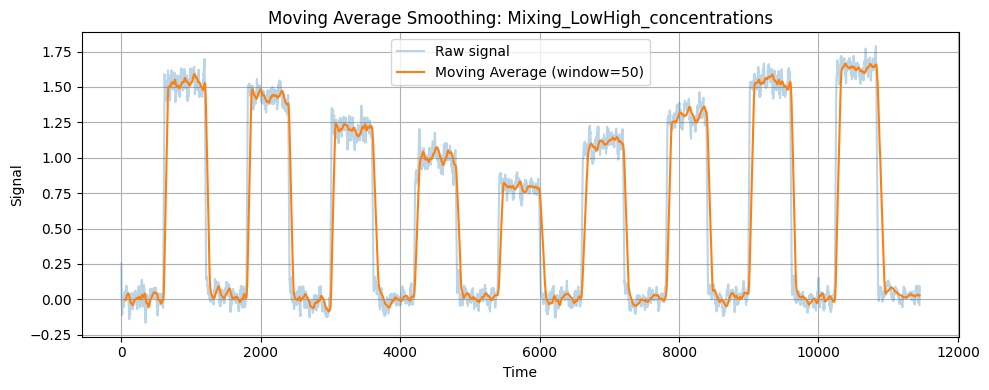

Mixing_LowHigh_concentrations | Run: UV ink-exposed to Toluene and 2 butanone | Repeat: nan


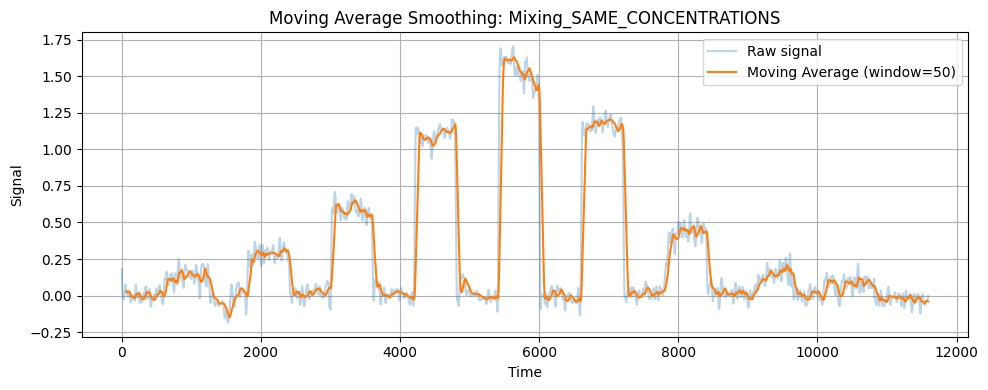

Mixing_SAME_CONCENTRATIONS | Run: 1 | Repeat: 1.0


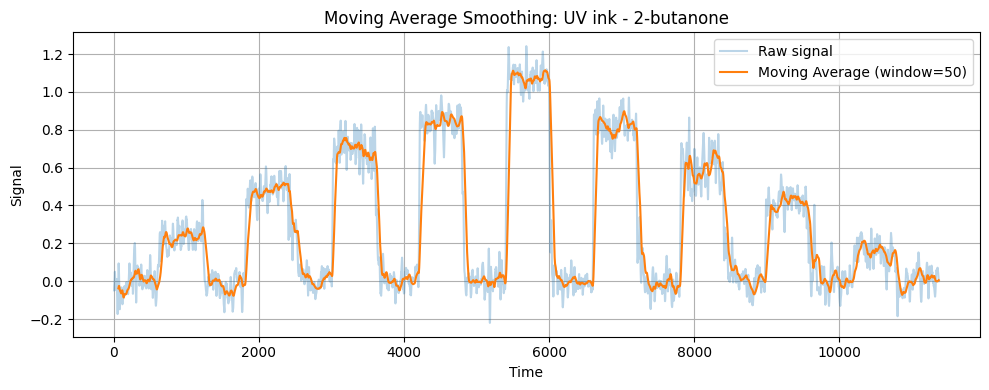

UV ink - 2-butanone | Run: 1 | Repeat: 1.0


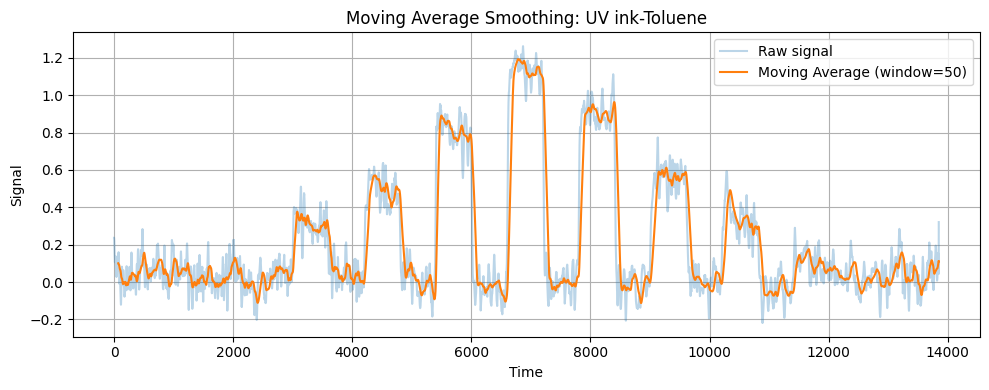

UV ink-Toluene | Run: 1 | Repeat: 1.0


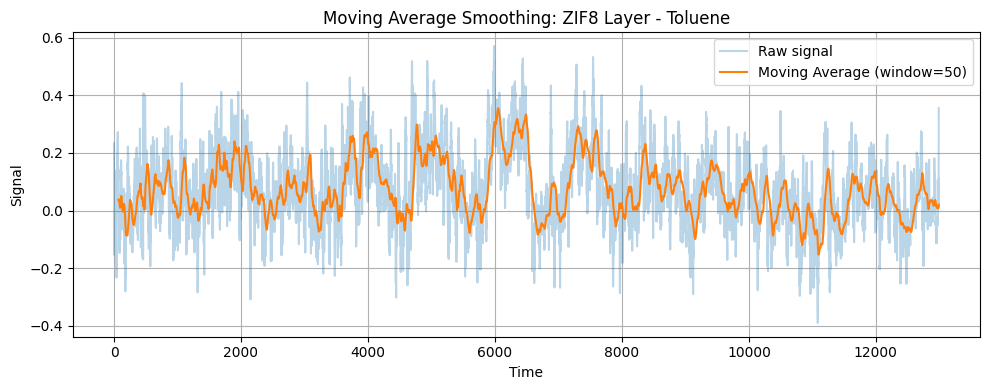

ZIF8 Layer - Toluene | Run: 1 | Repeat: 1.0


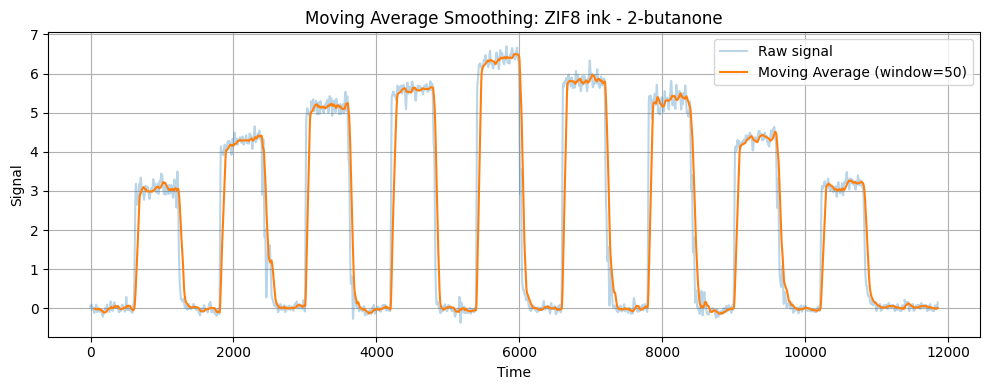

ZIF8 ink - 2-butanone | Run: 1 | Repeat: 1.0


In [14]:
import matplotlib.pyplot as plt

def plot_moving_average(loaded_runs, run_summary, window_size=50):
    plotted_exps = set()
    expected_experiments = set(run_summary['experiment_name'].unique())

    for run_path, content in loaded_runs.items():
        df = content['data'].copy()
        exp = content['experiment_name']
        repeat_index = content['repeat_index']

        if exp in plotted_exps:
            continue

        if df is None or df.empty:
            print(f"[WARN] Empty data for {run_path}")
            continue

        if 'time' not in df.columns or 'signal' not in df.columns:
            print(f"[WARN] Missing required columns in {run_path}")
            continue

        # Compute moving average
        df['moving_avg'] = df['signal'].rolling(window=window_size).mean()

        plt.figure(figsize=(10, 4))
        plt.plot(df['time'], df['signal'], alpha=0.3, label='Raw signal')
        plt.plot(df['time'], df['moving_avg'], label=f'Moving Average (window={window_size})')

        plt.title(f'Moving Average Smoothing: {exp}')
        plt.xlabel('Time')
        plt.ylabel('Signal')
        plt.legend()
        plt.tight_layout()
        plt.show()

        print(f"{exp} | Run: {run_path.name} | Repeat: {repeat_index}")

        plotted_exps.add(exp)

        if plotted_exps == expected_experiments:
            break

    return plotted_exps


moving_average_plotted_exps = plot_moving_average(loaded_runs, run_summary, window_size=50)

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Smoothing reduces high-frequency noise while preserving the main step-like response structure. Transitions between baseline and exposure phases become more clearly defined across all experiment groups.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
The underlying signal structure is robust to noise, with key temporal patterns remaining stable after smoothing. This indicates that the observed dynamics are driven by systematic processes rather than random fluctuations.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align: justify;">
Smoothing can support visualization and feature design (e.g., trend estimation), but should be applied cautiously in modeling to avoid distorting sharp transitions that may carry discriminative information.
</p>

<h2 style="color:#1B4F72; font-weight:bold;">
3.5 Rolling Variability
</h2>

<p style="font-size:17px; line-height:1.7; max-width:900px; text-align:justify;">
Rolling standard deviation is analyzed to localize transition regions and distinguish stable intervals from active response phases.
By computing variability within a sliding window, this analysis highlights where the signal undergoes rapid changes, while baseline and plateau regions exhibit lower and more stable variance.
</p>

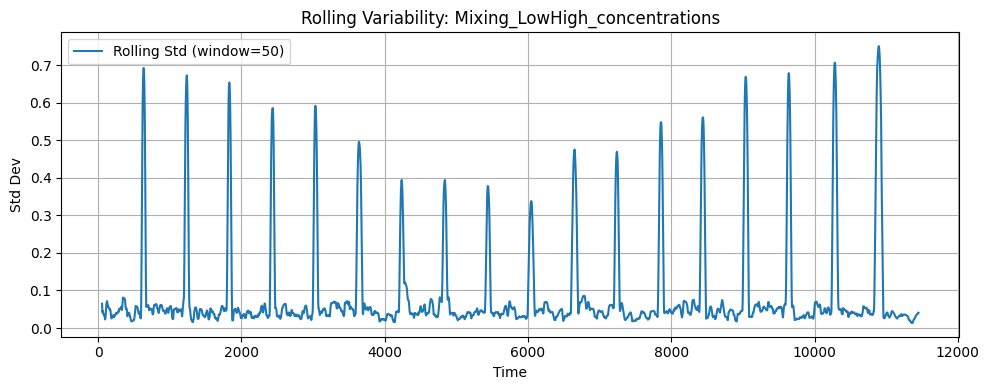

Mixing_LowHigh_concentrations | Run: UV ink-exposed to Toluene and 2 butanone | Repeat: nan


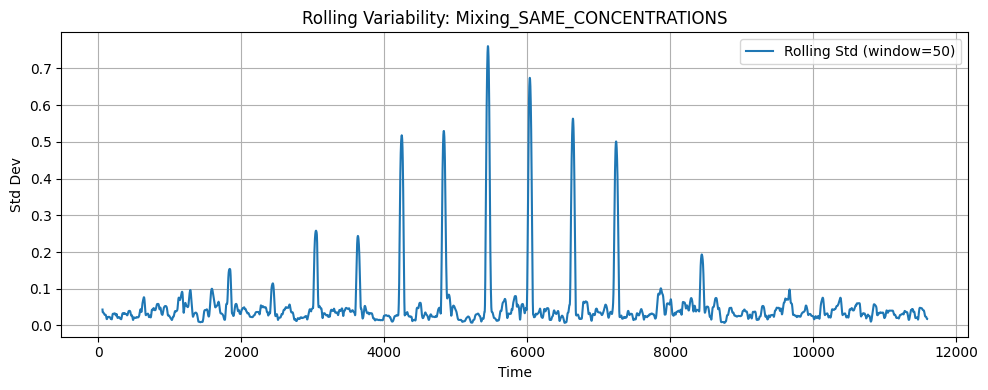

Mixing_SAME_CONCENTRATIONS | Run: 1 | Repeat: 1.0


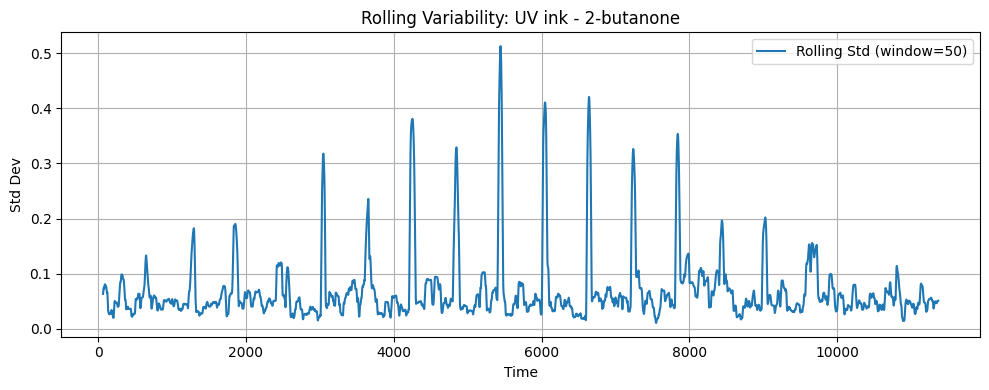

UV ink - 2-butanone | Run: 1 | Repeat: 1.0


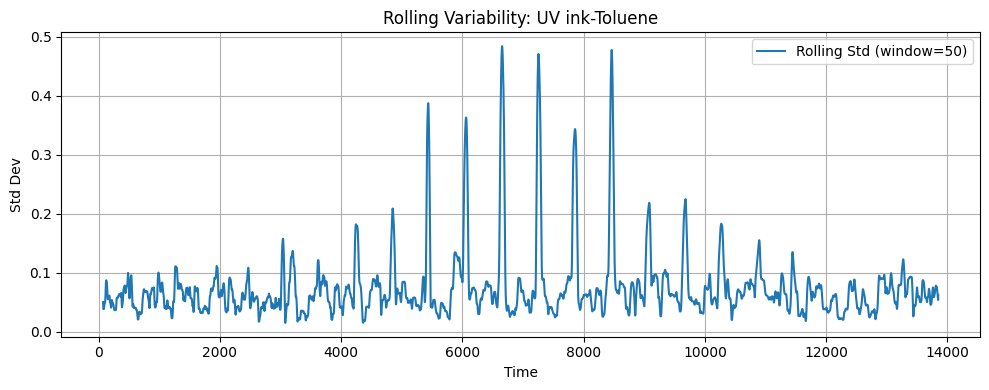

UV ink-Toluene | Run: 1 | Repeat: 1.0


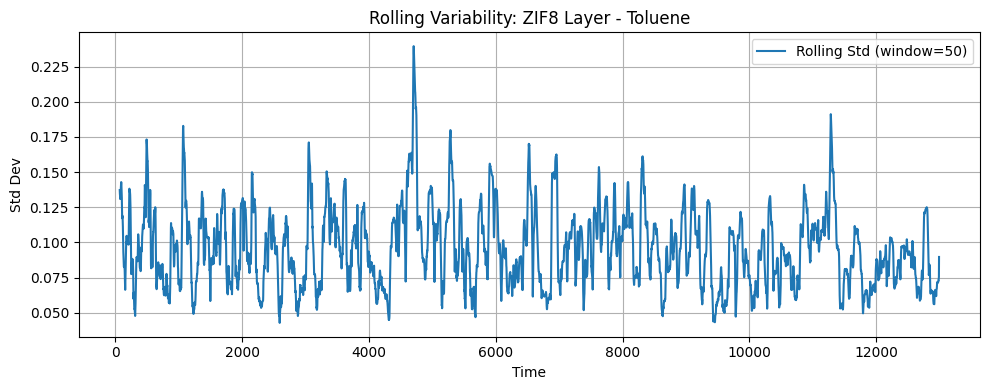

ZIF8 Layer - Toluene | Run: 1 | Repeat: 1.0


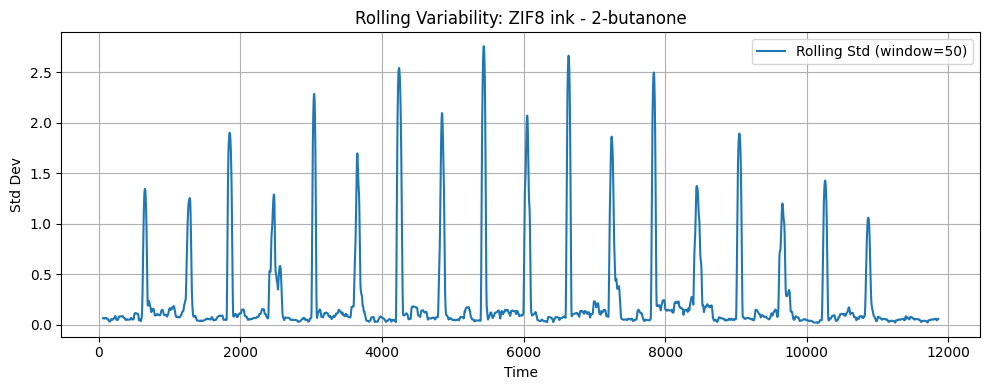

ZIF8 ink - 2-butanone | Run: 1 | Repeat: 1.0


In [15]:
import matplotlib.pyplot as plt

def plot_rolling_variance(loaded_runs, run_summary, window_size=50):
    plotted_exps = set()
    expected_experiments = set(run_summary['experiment_name'].unique())

    for run_path, content in loaded_runs.items():
        df = content['data'].copy()
        exp = content['experiment_name']
        repeat_index = content['repeat_index']

        if exp in plotted_exps:
            continue

        if df is None or df.empty:
            print(f"[WARN] Empty data for {run_path}")
            continue

        if 'time' not in df.columns or 'signal' not in df.columns:
            print(f"[WARN] Missing required columns in {run_path}")
            continue

        # Compute rolling std
        df['rolling_std'] = df['signal'].rolling(window=window_size).std()

        plt.figure(figsize=(10, 4))
        plt.plot(df['time'], df['rolling_std'], label=f'Rolling Std (window={window_size})')

        plt.title(f'Rolling Variability: {exp}')
        plt.xlabel('Time')
        plt.ylabel('Std Dev')
        plt.legend()
        plt.tight_layout()
        plt.show()

        print(f"{exp} | Run: {run_path.name} | Repeat: {repeat_index}")

        plotted_exps.add(exp)

        if plotted_exps == expected_experiments:
            break

    return plotted_exps


rolling_variance_plotted_exps = plot_rolling_variance(loaded_runs, run_summary, window_size=50)

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Across all experiment groups, sharp peaks in rolling standard deviation clearly align with transition periods between baseline and exposure phases.
In contrast, stable regions—both at low baseline levels and high plateau responses—exhibit consistently low variability.
The ZIF8 ink – 2-butanone experiment shows the most pronounced variability spikes, reflecting stronger dynamic changes, while the ZIF8 layer – toluene signal remains relatively noisy but without distinct sharp transitions.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The concentration of variability at transition points indicates that the system dynamics are primarily driven by changes in exposure conditions rather than random fluctuations.
Low variance during steady states suggests that sensor responses are stable and repeatable under constant conditions.
Differences in peak magnitude across experiments reflect varying sensitivity and response intensity of the sensing setups.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Rolling variability can be effectively used for detecting transition boundaries and segmenting time-series data into meaningful phases.
It provides a strong foundation for feature engineering, such as identifying change points or constructing variability-based features for classification models.
However, careful threshold selection is required to avoid over-sensitivity to minor fluctuations in noisier signals.
</p>

<h2 style="color:#1B4F72; font-weight:bold;">
3.6 Comparison Across Experiment Groups
</h2>

<p style="font-size:17px; line-height:1.7; max-width:900px; text-align:justify;">
Cross-run and cross-condition overlays are used to evaluate reproducibility, scale differences, and shape consistency within each experiment group.
By comparing multiple runs under similar conditions, this analysis reveals the degree of alignment in temporal patterns, signal amplitude, and noise characteristics across experiments.
</p>

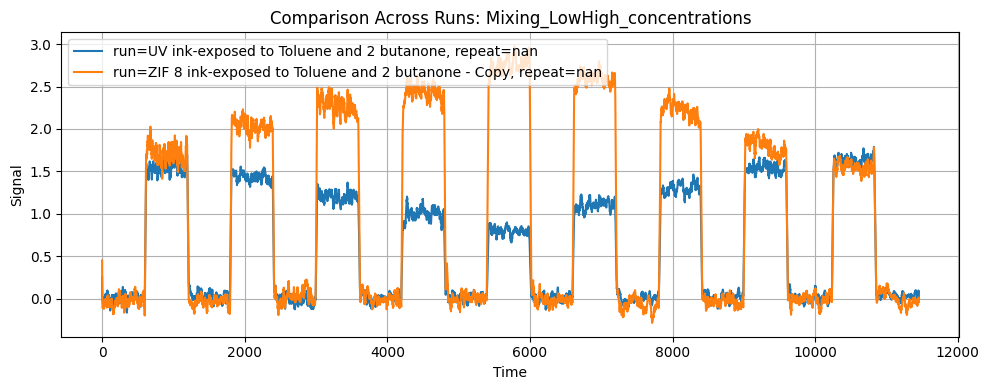

Interpretation for Mixing_LowHigh_concentrations:
  Mean: 0.81, Std: 0.92, Range: -0.29 to 2.98
  Interpretation: Noticeable variability across runs
--------------------------------------------------------------------------------


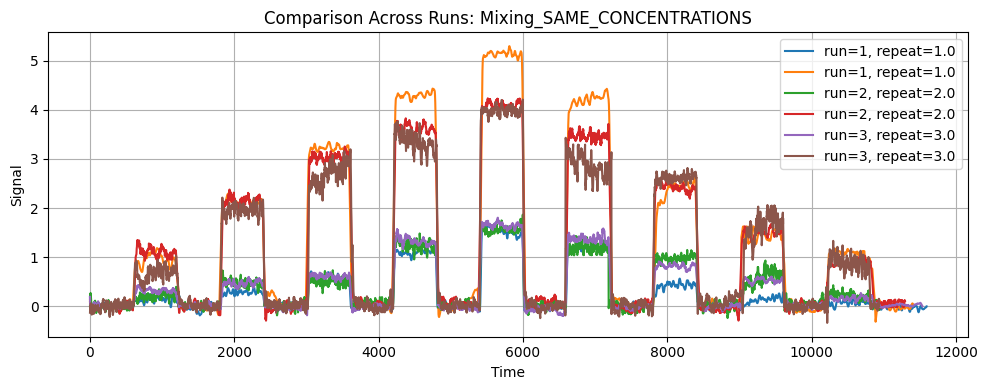

Interpretation for Mixing_SAME_CONCENTRATIONS:
  Mean: 0.77, Std: 1.19, Range: -0.34 to 5.30
  Interpretation: Noticeable variability across runs
--------------------------------------------------------------------------------


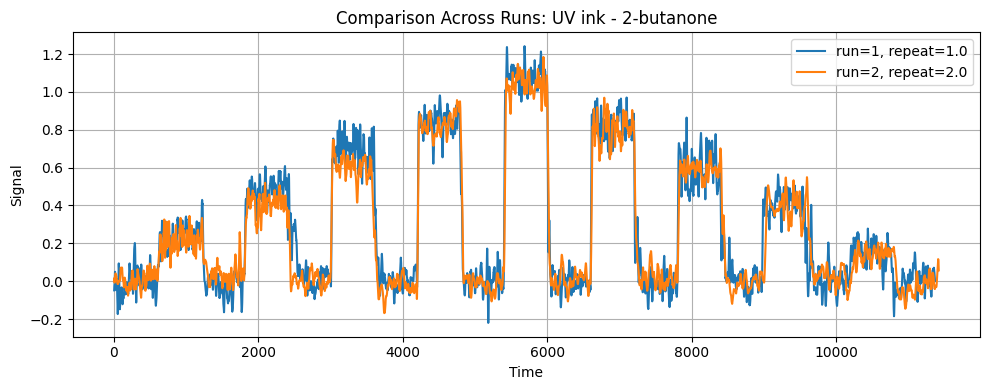

Interpretation for UV ink - 2-butanone:
  Mean: 0.28, Std: 0.34, Range: -0.22 to 1.24
  Interpretation: Noticeable variability across runs
--------------------------------------------------------------------------------


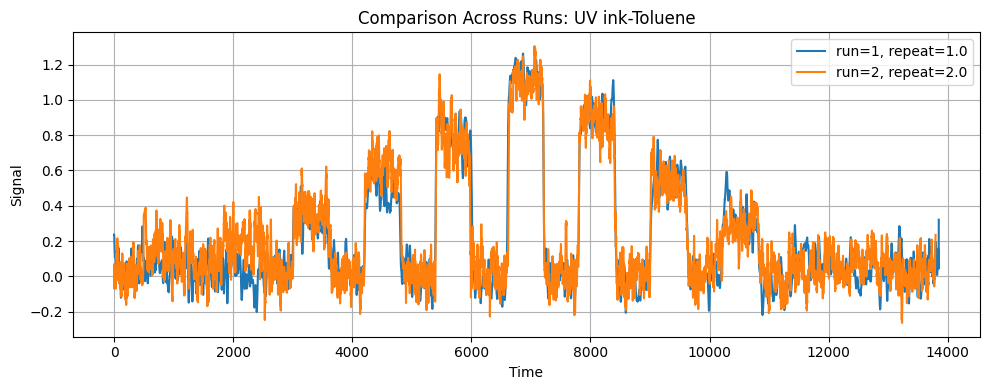

Interpretation for UV ink-Toluene:
  Mean: 0.22, Std: 0.33, Range: -0.26 to 1.30
  Interpretation: Noticeable variability across runs
--------------------------------------------------------------------------------


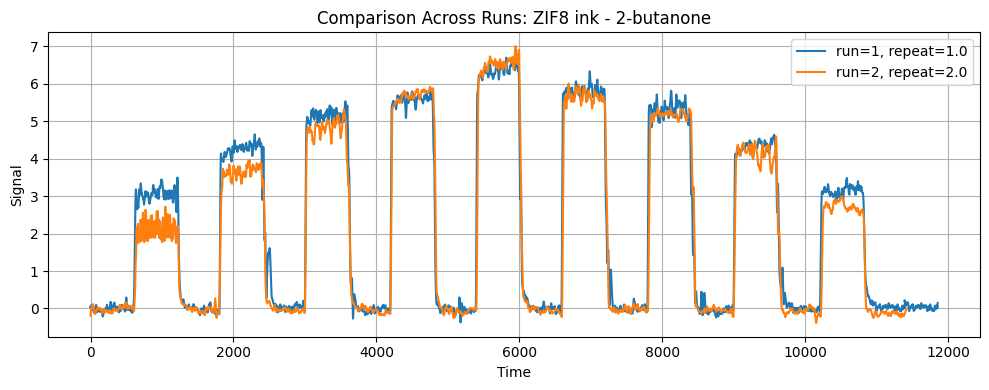

Interpretation for ZIF8 ink - 2-butanone:
  Mean: 2.18, Std: 2.42, Range: -0.39 to 7.01
  Interpretation: Noticeable variability across runs
--------------------------------------------------------------------------------


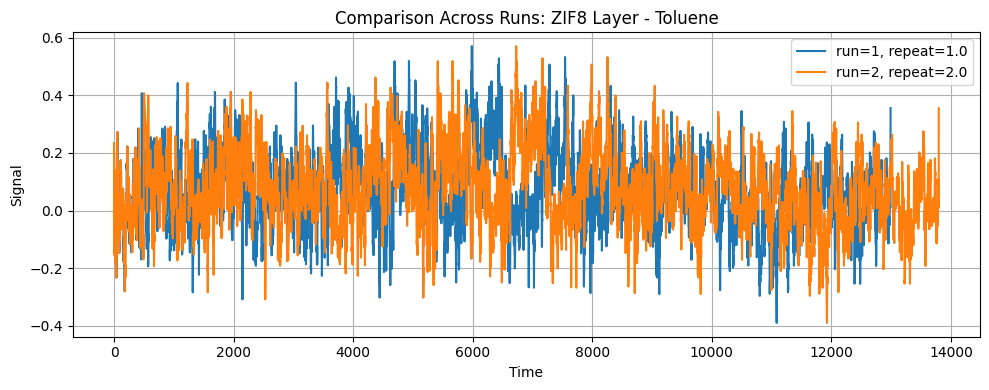

Interpretation for ZIF8 Layer - Toluene:
  Mean: 0.08, Std: 0.13, Range: -0.39 to 0.57
  Interpretation: Noticeable variability across runs
--------------------------------------------------------------------------------

Comparison plot counts per experiment group:
  Mixing_LowHigh_concentrations: 2 run(s) compared
  Mixing_SAME_CONCENTRATIONS: 6 run(s) compared
  UV ink - 2-butanone: 2 run(s) compared
  UV ink-Toluene: 2 run(s) compared
  ZIF8 Layer - Toluene: 2 run(s) compared
  ZIF8 ink - 2-butanone: 2 run(s) compared

Comparison coverage table:
Experiment Group | Runs Used in Comparison
Mixing_LowHigh_concentrations  | 2
Mixing_SAME_CONCENTRATIONS     | 6
UV ink - 2-butanone            | 2
UV ink-Toluene                 | 2
ZIF8 ink - 2-butanone          | 2
ZIF8 Layer - Toluene           | 2


In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Compare signal patterns across experiment groups
def plot_comparison_across_experiments(loaded_runs):
    required_experiments = [
        'Mixing_LowHigh_concentrations',
        'Mixing_SAME_CONCENTRATIONS',
        'UV ink - 2-butanone',
        'UV ink-Toluene',
        'ZIF8 ink - 2-butanone',
        'ZIF8 Layer - Toluene'
    ]

    plotted_exps = set()
    plot_counts = {}
    summary_rows = []

    for exp in required_experiments:
        # Select runs belonging to the current experiment group
        runs = [
            (run_path, content) for run_path, content in loaded_runs.items()
            if content['experiment_name'] == exp
        ]

        if not runs:
            print(f"[WARNING] No loaded runs for experiment group: {exp}")
            continue

        plt.figure(figsize=(10, 4))
        signals_for_summary = []

        for run_path, content in runs:
            df = content['data']
            repeat_index = content['repeat_index']

            if df is None or df.empty:
                continue
            if 'time' not in df.columns or 'signal' not in df.columns:
                continue

            plt.plot(df['time'], df['signal'], label=f"run={run_path.name}, repeat={repeat_index}")
            signals_for_summary.append(df['signal'].dropna())

        plt.title(f'Comparison Across Runs: {exp}')
        plt.xlabel('Time')
        plt.ylabel('Signal')
        plt.legend()
        plt.tight_layout()
        plt.show()

        if len(signals_for_summary) == 0:
            print(f"[WARNING] No valid signal data available for experiment group: {exp}")
            continue

        all_signals = pd.concat(signals_for_summary, ignore_index=True)

        mean_val = all_signals.mean()
        std_val = all_signals.std()
        min_val = all_signals.min()
        max_val = all_signals.max()

        if mean_val != 0 and std_val > 0.1 * abs(mean_val):
            interpretation = "Noticeable variability across runs"
        else:
            interpretation = "Relatively consistent signal behavior across runs"

        print(f"Interpretation for {exp}:")
        print(f"  Mean: {mean_val:.2f}, Std: {std_val:.2f}, Range: {min_val:.2f} to {max_val:.2f}")
        print(f"  Interpretation: {interpretation}")
        print("-" * 80)

        summary_rows.append({
            'experiment_name': exp,
            'num_runs_compared': len(runs),
            'mean': mean_val,
            'std': std_val,
            'min': min_val,
            'max': max_val,
            'interpretation': interpretation
        })

        plotted_exps.add(exp)
        plot_counts[exp] = len(runs)

    print("\nComparison plot counts per experiment group:")
    for exp in sorted(plot_counts):
        print(f"  {exp}: {plot_counts[exp]} run(s) compared")

    print("\nComparison coverage table:")
    print("Experiment Group | Runs Used in Comparison")
    for exp in required_experiments:
        print(f"{exp:30} | {plot_counts.get(exp, 0)}")

    summary_df = pd.DataFrame(summary_rows)

    return plotted_exps, plot_counts, summary_df


# Ensure variables are always defined
comparison_plotted_exps = set()
comparison_plot_counts = {}
comparison_summary_df = pd.DataFrame()

try:
    comparison_plotted_exps, comparison_plot_counts, comparison_summary_df = plot_comparison_across_experiments(
        loaded_runs
    )
except Exception as e:
    print(f"[ERROR] Comparison plotting failed: {e}")

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Across all experiment groups, the general step-like response pattern is consistently preserved, indicating similar temporal behavior across runs.
However, noticeable differences in signal amplitude and variability are observed. In Mixing experiments, runs follow similar shapes but differ in magnitude, especially under SAME_CONCENTRATIONS where multiple runs exhibit clear spread.
UV ink experiments show relatively good alignment between runs, with minor deviations mainly in noise levels.
In contrast, ZIF8 ink – 2-butanone exhibits significant scale differences between runs, while ZIF8 layer – toluene displays high noise with overlapping signals, making individual runs less distinguishable.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The consistent temporal structure across runs suggests that the underlying process is stable and repeatable in terms of response timing.
Variations in amplitude indicate differences in sensitivity or experimental conditions, while increased noise levels in certain setups (e.g., ZIF8 layer) suggest lower signal-to-noise ratios.
Higher variability across runs in some groups reflects reduced reproducibility, potentially due to environmental factors or material behavior.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
While temporal patterns can be reliably used for modeling, amplitude normalization or scaling may be necessary to handle cross-run differences.
Variability across runs highlights the importance of robust feature extraction methods that are less sensitive to noise and magnitude shifts.
Additionally, experiment groups with high reproducibility (e.g., UV ink) are more suitable for modeling, whereas noisier signals may require additional preprocessing or noise reduction techniques.
</p>

<h2 style="color:#1B4F72; font-weight:bold;">
3.7 Data Quality Check
</h2>

<p style="font-size:17px; line-height:1.7; max-width:900px; text-align:justify;">
Data quality is reviewed for missingness, zero values, time-index consistency, and sequence-length variability to confirm reliability of the explored signals.
This step ensures that the dataset is structurally sound and suitable for downstream analysis and modeling without requiring major preprocessing corrections.
</p>

In [17]:
import pandas as pd

# Assess data quality for each loaded run
quality_rows = []

for run_path, content in loaded_runs.items():
    df = content['data']
    exp = content['experiment_name']
    repeat_index = content['repeat_index']

    if df is None or df.empty:
        continue

    if 'time' not in df.columns or 'signal' not in df.columns:
        continue

    missing = df['signal'].isnull().sum()
    zeros = (df['signal'] == 0).sum()
    length = len(df)
    unique_time = df['time'].nunique()
    mean_val = df['signal'].mean()
    std_val = df['signal'].std()

    if missing > 0:
        interpretation = "Missing values are present and may affect signal continuity."
    elif zeros > 0:
        interpretation = "Zero-valued segments are present and may indicate inactive or baseline periods."
    elif length != unique_time:
        interpretation = "Non-unique time values suggest possible irregular sampling or duplicated timestamps."
    else:
        interpretation = "No major quality issues are immediately visible in this run."

    quality_rows.append({
        'experiment_name': exp,
        'run_name': run_path.name,
        'repeat_index': repeat_index,
        'missing_signal_values': missing,
        'zero_signal_values': zeros,
        'sequence_length': length,
        'unique_time_values': unique_time,
        'signal_mean': mean_val,
        'signal_std': std_val,
        'interpretation': interpretation
    })

quality_df = pd.DataFrame(quality_rows)
quality_df.head()

,experiment_name,run_name,repeat_index,missing_signal_values,zero_signal_values,sequence_length,unique_time_values,signal_mean,signal_std,interpretation
0,Mixing_LowHigh_concentrations,UV ink-exposed to Toluene and 2 butanone,NaN,0,3,7748,7748,0.613219,0.656444,Zero-valued segments are present and may indic...
1,Mixing_LowHigh_concentrations,ZIF 8 ink-exposed to Toluene and 2 butanone - ...,NaN,0,6,7748,7748,1.000285,1.097371,Zero-valued segments are present and may indic...
2,Mixing_SAME_CONCENTRATIONS,1,1.0,0,6,8061,8049,0.276641,0.448685,Zero-valued segments are present and may indic...
3,Mixing_SAME_CONCENTRATIONS,1,1.0,0,4,7954,7954,1.291642,1.639526,Zero-valued segments are present and may indic...
4,Mixing_SAME_CONCENTRATIONS,2,2.0,0,6,7487,7487,0.378994,0.493376,Zero-valued segments are present and may indic...


<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
No missing signal values are observed across all experiment groups, indicating complete data availability.
A small number of zero-valued samples appear in several runs, likely corresponding to baseline or inactive sensor states rather than data corruption.
Sequence lengths are generally consistent within each experiment group, with only minor variations across runs.
Additionally, the number of unique time values closely matches the sequence length in all cases, confirming proper time indexing without duplication or gaps.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The absence of missing values suggests that data collection and storage processes are reliable and do not introduce structural gaps.
Zero-valued segments are consistent with expected system behavior during baseline phases and do not indicate anomalies.
Minor differences in sequence length are likely due to experimental duration variations rather than data quality issues.
Overall, the dataset demonstrates strong structural integrity and temporal consistency.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Minimal preprocessing is required before modeling, as no imputation or time alignment correction is necessary.
Zero-value handling may be considered depending on the modeling approach, especially if baseline segments need to be separated from active response phases.
Consistent sequence structure supports reliable feature extraction and simplifies downstream pipeline design.
</p>

<h2 style="color:#1B4F72; font-weight:bold;">
4. Key Insights
</h2>

<p style="font-size:17px; line-height:1.7; max-width:900px; text-align:justify;">
The exploratory analysis reveals several consistent patterns that define the structure and behavior of the dataset.
These insights provide a foundation for designing a robust and interpretable preprocessing pipeline.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Temporal response shape emerges as the primary carrier of information, with clear step-like transitions between baseline and exposure phases.
Different gas conditions, coating types, and concentration schedules produce distinct response magnitudes and temporal dynamics.
Signals are inherently non-stationary, often exhibiting multiple regimes such as stable baselines, transition peaks, and plateau regions.
Additionally, noticeable variability exists across runs, even under similar experimental conditions.
Despite these complexities, the dataset maintains high structural quality with no missing values and consistent time indexing.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The dominance of temporal patterns indicates that static statistical features alone are insufficient, and time-dependent representations are essential.
Non-stationarity and multi-regime behavior suggest that the signal cannot be modeled as a single homogeneous process.
Run-to-run variability highlights the presence of experimental or environmental differences that must be explicitly accounted for during modeling.
Overall, the dataset is rich in structure but requires careful handling to avoid losing critical temporal information.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Modeling approaches should prioritize temporal feature extraction, such as window-based representations or sequence models.
Normalization and scaling must be applied carefully to ensure comparability across runs without removing meaningful amplitude differences.
Run-level grouping and metadata preservation are essential to prevent data leakage and maintain experimental context.
Preprocessing should explicitly handle variability and non-stationarity rather than attempting to eliminate them.
</p>

<h2 style="color:#1B4F72; font-weight:bold;">
5. Preprocessing Design
</h2>

<p style="font-size:17px; line-height:1.7; max-width:900px; text-align:justify;">
Based on the previous analysis, preprocessing is designed to preserve temporal meaning while improving comparability across runs.
The goal is to prepare the data for modeling without distorting its underlying structure.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Design Principles
</h3>

<ul style="font-size:17px; margin-left:40px; line-height:1.8; max-width:900px;">
  <li>Preserve run identity and experimental metadata to maintain contextual integrity.</li>
  <li>Standardize signal scale across runs to enable fair comparison and stable model training.</li>
  <li>Reduce high-frequency noise while preserving key temporal structures such as transitions and plateaus.</li>
  <li>Transform variable-length sequences into consistent learning units suitable for machine learning models.</li>
</ul>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The preprocessing strategy reflects a balance between signal integrity and model readiness.
Rather than aggressively simplifying the data, the design focuses on retaining meaningful temporal patterns while improving consistency across samples.
Each step in the pipeline is guided by observed characteristics of the data, ensuring alignment between data preparation and modeling objectives.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
This design enables the development of models that are robust to variability and sensitive to temporal dynamics.
It also facilitates reproducibility and scalability within the MLOps pipeline by enforcing consistent preprocessing rules across all runs.
Ultimately, the pipeline supports both exploratory analysis and downstream predictive modeling in a unified framework.
</p>

<h2 style="color:#1B4F72; font-weight:bold;">
5.1 Unified Preprocessed Structure
</h2>

<p style="font-size:17px; line-height:1.7; max-width:900px; text-align:justify;">
All valid runs are consolidated into a single run-indexed dataframe that integrates experiment labels, run identifiers, repeat indices, and summary signal statistics.
This unified structure serves as the canonical representation of the dataset for all subsequent preprocessing and modeling stages.
</p>

In [18]:
from pathlib import Path
import pandas as pd

def build_master_dataframe(loaded_runs):
    records = []

    for run_path, content in loaded_runs.items():
        df = content["data"].copy()
        experiment_name = content.get("experiment_name", "unknown")
        experiment_folder = content.get("experiment_folder", "unknown")
        repeat_index = content.get("repeat_index", None)

        if "time" not in df.columns or "signal" not in df.columns:
            continue

        run_path_obj = Path(run_path)

        # Unique run identifier with NaN-safe repeat handling.
        if pd.notna(repeat_index):
            repeat_value = int(repeat_index) if float(repeat_index).is_integer() else repeat_index
            run_id = f"{experiment_name}__run_{repeat_value}"
        else:
            run_id = f"{experiment_name}__{run_path_obj.name}"

        run_folder = str(run_path_obj)

        temp = df[["time", "signal"]].copy()
        temp["experiment"] = experiment_name
        temp["experiment_folder"] = experiment_folder
        temp["run_id"] = run_id
        temp["run_folder"] = run_folder
        temp["repeat_index"] = repeat_index

        records.append(temp)

    if not records:
        raise ValueError("No valid runs were found in loaded_runs to build the master dataframe.")

    master_df = pd.concat(records, ignore_index=True)

    master_df = master_df[
        ["experiment", "experiment_folder", "run_id", "run_folder", "repeat_index", "time", "signal"]
    ]

    return master_df


master_df = build_master_dataframe(loaded_runs)

print("Master dataframe shape:", master_df.shape)
display(
    master_df.groupby(["experiment", "run_id", "repeat_index"])
    .agg(
        n_points=("signal", "size"),
        min_signal=("signal", "min"),
        max_signal=("signal", "max"),
        mean_signal=("signal", "mean"),
        std_signal=("signal", "std"),
    )
    .reset_index()
    .sort_values(["experiment", "repeat_index", "run_id"])
    .head(20)
)

Master dataframe shape: (118610, 7)


,experiment,run_id,repeat_index,n_points,min_signal,max_signal,mean_signal,std_signal
0,Mixing_SAME_CONCENTRATIONS,Mixing_SAME_CONCENTRATIONS__run_1,1.0,16015,-0.31543,5.29505,0.780751,1.301478
1,Mixing_SAME_CONCENTRATIONS,Mixing_SAME_CONCENTRATIONS__run_2,2.0,13453,-0.29372,4.23297,0.741262,1.102910
2,Mixing_SAME_CONCENTRATIONS,Mixing_SAME_CONCENTRATIONS__run_3,3.0,13374,-0.33915,4.20798,0.799589,1.128839
3,UV ink - 2-butanone,UV ink - 2-butanone__run_1,1.0,7899,-0.22006,1.24157,0.284176,0.355733
4,UV ink - 2-butanone,UV ink - 2-butanone__run_2,2.0,6400,-0.16859,1.18476,0.263817,0.329483
5,UV ink-Toluene,UV ink-Toluene__run_1,1.0,8234,-0.21850,1.26248,0.203974,0.327807
6,UV ink-Toluene,UV ink-Toluene__run_2,2.0,7692,-0.26380,1.30464,0.234752,0.324824
7,ZIF8 Layer - Toluene,ZIF8 Layer - Toluene__run_1,1.0,7700,-0.38943,0.57030,0.075050,0.134691
8,ZIF8 Layer - Toluene,ZIF8 Layer - Toluene__run_2,2.0,7700,-0.38943,0.57030,0.075050,0.134691
9,ZIF8 ink - 2-butanone,ZIF8 ink - 2-butanone__run_1,1.0,8243,-0.37251,6.70134,2.221389,2.443245


<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The aggregated dataframe includes multiple experiment groups with consistent schema across all runs.
Each run is uniquely identified and associated with metadata such as experiment type and repeat index.
Signal statistics (minimum, maximum, mean, and standard deviation) reveal clear differences in scale across experiment groups, with some configurations (e.g., ZIF8 ink) exhibiting significantly higher amplitude and variability.
Sequence lengths vary across runs, reflecting differences in experimental duration or sampling.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The presence of a unified structure confirms that the dataset has been successfully standardized at the run level while preserving essential experimental distinctions.
Variations in signal scale and sequence length indicate that direct comparison across runs is not inherently reliable without further normalization.
At the same time, maintaining run-level separation ensures that temporal and contextual integrity is not lost.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
This unified representation provides a solid foundation for downstream preprocessing steps such as scaling, smoothing, and segmentation.
Normalization techniques must be applied to address scale differences across experiments, while windowing strategies are required to handle variable-length sequences.
Preserving run identifiers enables proper grouping, prevents data leakage, and supports robust model validation.
</p>

<h2 style="color:#1B4F72; font-weight:bold;">
5.2 Run-Level Normalization
</h2>

<p style="font-size:17px; line-height:1.7; max-width:900px; text-align:justify;">
Min-Max normalization is applied independently to each run in order to scale signals into a common range.
This approach preserves the temporal structure within each run while enabling consistent comparison across different experimental conditions.
</p>

<p style="font-size:17px; line-height:1.7; max-width:900px; text-align:justify;">
By transforming each signal to the [0, 1] range, differences in absolute amplitude are reduced, allowing the analysis to focus on relative temporal dynamics such as transitions, plateaus, and response patterns.
</p>

In [19]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def normalize_per_run(df):
    df = df.copy()
    normalized_groups = []

    for run_id, group in df.groupby("run_id"):
        group = group.copy()

        if group["signal"].nunique() <= 1:
            group["signal_norm"] = 0.0
        else:
            scaler = MinMaxScaler()
            group["signal_norm"] = scaler.fit_transform(group[["signal"]])

        normalized_groups.append(group)

    normalized_df = pd.concat(normalized_groups, ignore_index=True)
    return normalized_df


master_df = normalize_per_run(master_df)
master_df["signal_norm"].describe()

count    118610.000000
mean          0.319645
std           0.271298
min           0.000000
25%           0.080576
50%           0.210915
75%           0.520227
max           1.000000
Name: signal_norm, dtype: float64

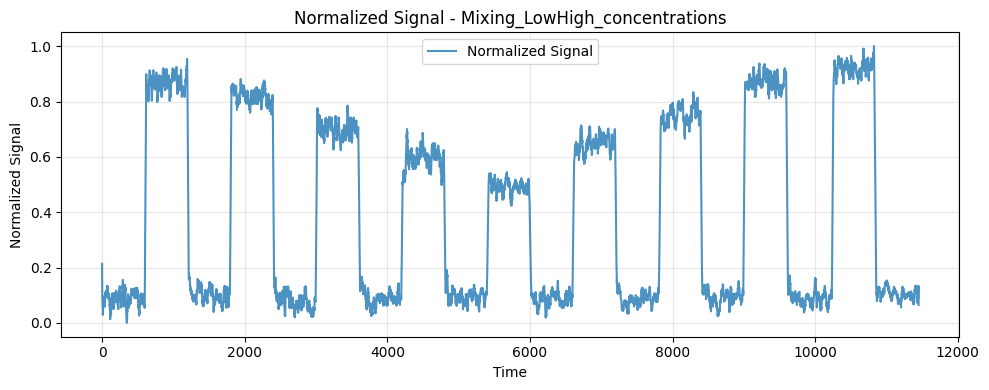

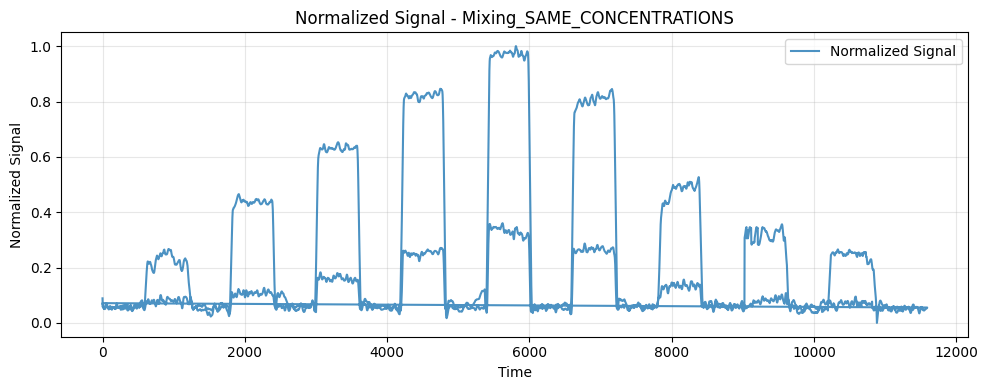

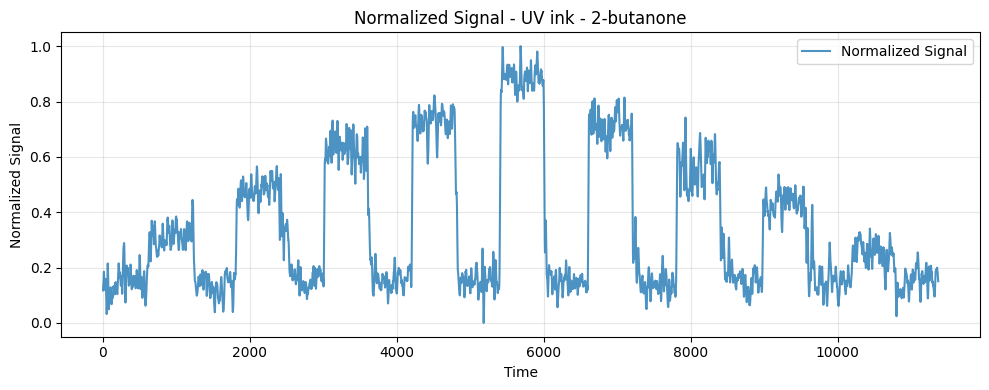

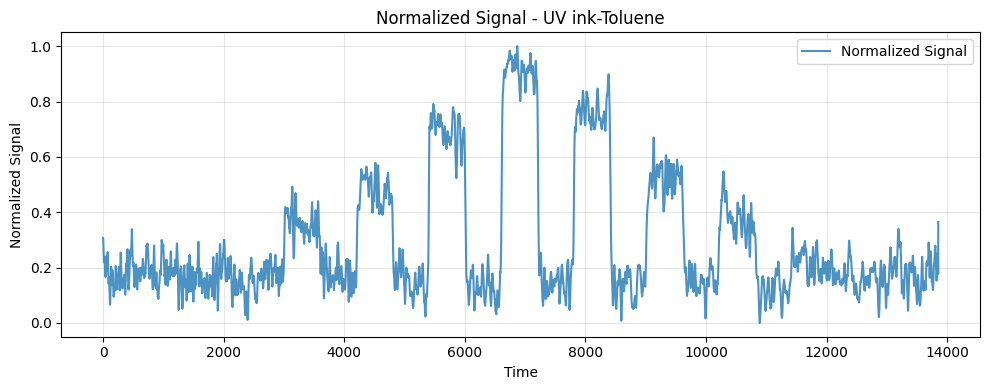

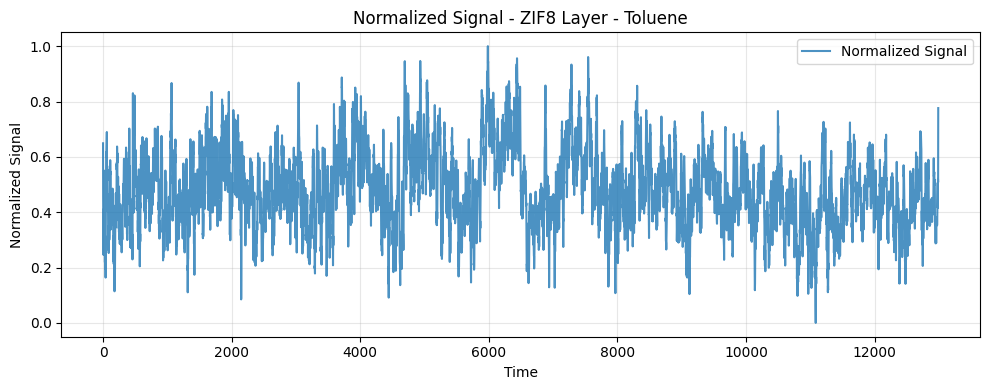

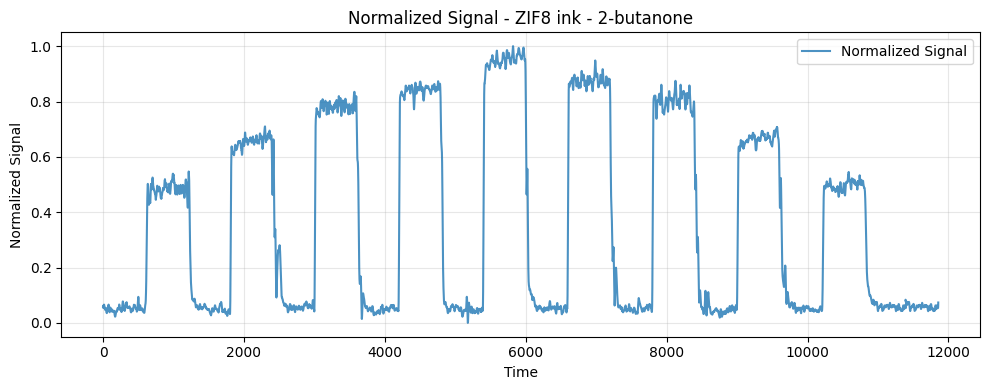

In [22]:
import matplotlib.pyplot as plt

experiments = master_df["experiment"].unique()

for exp in experiments:
    plt.figure(figsize=(10, 4))
    
    run_id = master_df[master_df["experiment"] == exp]["run_id"].iloc[0]
    temp = master_df[master_df["run_id"] == run_id]
    
    plt.plot(temp["time"], temp["signal_norm"], alpha=0.8, label="Normalized Signal")
    
    plt.title(f"Normalized Signal - {exp}")
    plt.xlabel("Time")
    plt.ylabel("Normalized Signal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
After applying run-level normalization, all signals are scaled to a common range, making their temporal patterns directly comparable across experiments.
Step-like response structures remain clearly visible, including transitions between baseline, rising edges, and plateau regions.
While amplitude differences across experiments are removed, variations in noise levels and signal smoothness are still observable, particularly in configurations such as ZIF8 Layer, which retains higher fluctuation intensity.
Overall, the normalized signals exhibit consistent structural behavior while highlighting differences in temporal dynamics rather than magnitude.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Normalization effectively eliminates scale dominance, allowing the analysis to focus on intrinsic response shapes.
The preservation of step transitions confirms that Min-Max scaling does not distort temporal morphology, which is critical for downstream modeling.
Differences in noise characteristics across experiments indicate that normalization alone does not homogenize signal quality, and additional preprocessing (e.g., smoothing or filtering) may be beneficial.
This behavior reinforces that temporal structure, rather than absolute amplitude, is the key discriminative feature in the dataset.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Run-level normalization enables fair comparison and stable model training by placing all signals on a consistent scale.
It prepares the data for feature extraction and learning algorithms that rely on relative patterns rather than raw magnitude.
However, since noise characteristics remain present, subsequent steps such as smoothing or feature engineering should be considered to improve signal quality.
Importantly, normalization should always be applied at the run level to avoid leakage and preserve experimental independence.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
5.3 Smoothing Strategy
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
To reduce high-frequency noise while preserving meaningful signal structure, Savitzky-Golay filtering is applied at the run level.
This method performs local polynomial fitting within a sliding window, enabling effective smoothing without distorting sharp transitions or peak characteristics.
Compared to simpler techniques such as moving averages, it better maintains the original temporal morphology of the signal.
As a result, the smoothed signals retain their interpretability while becoming more suitable for downstream analysis and feature extraction.
</p>

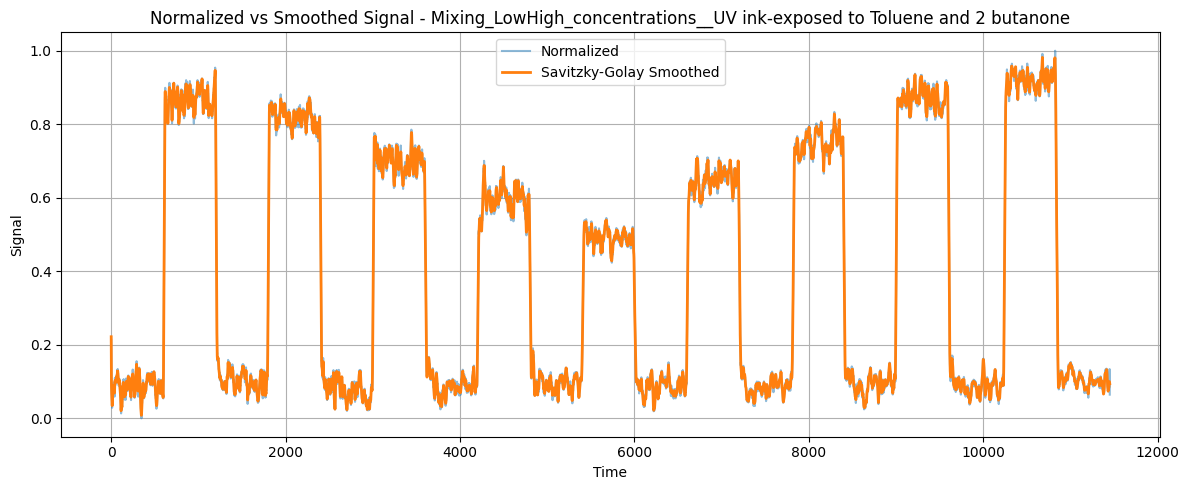

In [23]:
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

def apply_savgol_smoothing(df, window_length=9, polyorder=2):
    df = df.copy()
    df = df.sort_values(["run_id", "time"])

    def smooth_group(x):
        x = x.copy()

        # Ensure valid odd window length and enough points
        n = len(x)
        if n < 3:
            return x

        wl = min(window_length, n if n % 2 == 1 else n - 1)
        if wl < 3:
            return x
        if wl <= polyorder:
            wl = polyorder + 1
            if wl % 2 == 0:
                wl += 1
            if wl > n:
                return x

        return savgol_filter(x, window_length=wl, polyorder=polyorder)

    master = df.groupby("run_id", group_keys=False)["signal_norm"].transform(smooth_group)
    df["signal_smooth"] = master

    return df


master_df = apply_savgol_smoothing(master_df, window_length=9, polyorder=2)

sample_run = master_df["run_id"].iloc[0]
temp = master_df[master_df["run_id"] == sample_run].sort_values("time")

plt.figure(figsize=(12, 5))
plt.plot(temp["time"], temp["signal_norm"], label="Normalized", alpha=0.5)
plt.plot(temp["time"], temp["signal_smooth"], label="Savitzky-Golay Smoothed", linewidth=2)

plt.title(f"Normalized vs Smoothed Signal - {sample_run}")
plt.xlabel("Time")
plt.ylabel("Signal")
plt.legend()
plt.tight_layout()
plt.show()

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Savitzky-Golay smoothing significantly reduces high-frequency noise while preserving the overall step-like structure of the signal.
Transitions between baseline and exposure phases remain sharp and well-defined, with minimal distortion in peak positions and plateau levels.
Compared to the normalized signal, the smoothed signal exhibits more stable trajectories within each phase, with reduced fluctuations around constant regions.
The alignment between the original and smoothed signals indicates that the filtering process maintains temporal consistency.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The Savitzky-Golay filter effectively removes local noise without compromising important structural features such as edges and response dynamics.
Unlike simple moving averages, this method preserves the shape and curvature of the signal, making it suitable for time-series with sharp transitions.
The reduced variance within stable regions suggests improved signal quality, which can enhance the reliability of downstream feature extraction.
This confirms that the chosen smoothing strategy balances noise reduction and structural preservation.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Smoothing prepares the signals for more robust feature engineering by minimizing noise-induced variability.
It is particularly beneficial for detecting transition points, extracting trends, and computing derivatives or statistical features.
However, the choice of window length and polynomial order remains critical, as overly aggressive smoothing may blur subtle but informative variations.
Applying smoothing at the run level ensures that signal integrity and experimental independence are preserved.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
5.4 Windowing for Consistent Inputs
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Variable-length runs are transformed into fixed-length segments using a sliding window approach.
Each window captures a localized portion of the signal while maintaining temporal continuity within the run.
This representation enables the conversion of irregular time-series into uniform samples suitable for machine learning models.
By preserving the original signal order and structure within each window, meaningful temporal patterns remain accessible for feature extraction and classification tasks.
</p>

Windowed dataframe shape: (2353, 11)


,run_id,experiment,experiment_folder,run_folder,repeat_index,window_id,start_idx,end_idx,time_start,time_end,signal_window
0,Mixing_LowHigh_concentrations__UV ink-exposed ...,Mixing_LowHigh_concentrations,Mixing_LowHigh concentrastions,..\data\raw\CMOS_addtional_datasets\Mixing_Low...,NaN,Mixing_LowHigh_concentrations__UV ink-exposed ...,0,99,0.000,115.869,"[0.22191272881048008, 0.1788521326708596, 0.14..."
1,Mixing_LowHigh_concentrations__UV ink-exposed ...,Mixing_LowHigh_concentrations,Mixing_LowHigh concentrastions,..\data\raw\CMOS_addtional_datasets\Mixing_Low...,NaN,Mixing_LowHigh_concentrations__UV ink-exposed ...,50,149,58.252,175.526,"[0.10882198394731375, 0.10867808536671446, 0.1..."
2,Mixing_LowHigh_concentrations__UV ink-exposed ...,Mixing_LowHigh_concentrations,Mixing_LowHigh concentrastions,..\data\raw\CMOS_addtional_datasets\Mixing_Low...,NaN,Mixing_LowHigh_concentrations__UV ink-exposed ...,100,199,117.016,234.546,"[0.03248668794186581, 0.03501793439588855, 0.0..."
3,Mixing_LowHigh_concentrations__UV ink-exposed ...,Mixing_LowHigh_concentrations,Mixing_LowHigh concentrastions,..\data\raw\CMOS_addtional_datasets\Mixing_Low...,NaN,Mixing_LowHigh_concentrations__UV ink-exposed ...,150,249,176.640,293.550,"[0.08211229917865742, 0.07837054760784211, 0.0..."
4,Mixing_LowHigh_concentrations__UV ink-exposed ...,Mixing_LowHigh_concentrations,Mixing_LowHigh concentrastions,..\data\raw\CMOS_addtional_datasets\Mixing_Low...,NaN,Mixing_LowHigh_concentrations__UV ink-exposed ...,200,299,235.821,352.716,"[0.09998657123741517, 0.10686870133679063, 0.1..."


Number of runs represented: 13
Number of experiments represented: 6


,num_windows
experiment,
Mixing_SAME_CONCENTRATIONS,853
UV ink-Toluene,315
Mixing_LowHigh_concentrations,306
ZIF8 Layer - Toluene,306
ZIF8 ink - 2-butanone,290
UV ink - 2-butanone,283


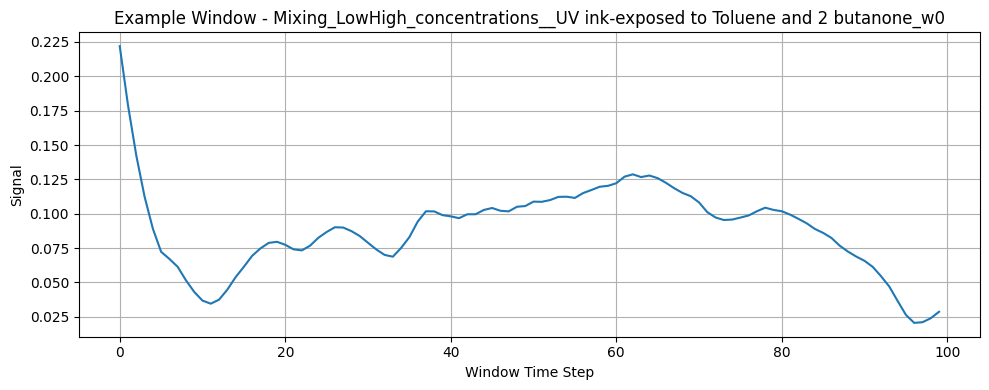

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

def create_fixed_windows(df, signal_col="signal_smooth", window_size=100, step_size=50):
    window_records = []

    for run_id, group in df.groupby("run_id"):
        group = group.sort_values("time").reset_index(drop=True)

        experiment = group["experiment"].iloc[0]
        experiment_folder = group["experiment_folder"].iloc[0]
        run_folder = group["run_folder"].iloc[0]
        repeat_index = group["repeat_index"].iloc[0]

        signal_values = group[signal_col].values
        time_values = group["time"].values

        if len(group) < window_size:
            continue

        for start in range(0, len(group) - window_size + 1, step_size):
            end = start + window_size

            window_signal = signal_values[start:end]
            window_time_start = time_values[start]
            window_time_end = time_values[end - 1]

            window_records.append({
                "run_id": run_id,
                "experiment": experiment,
                "experiment_folder": experiment_folder,
                "run_folder": run_folder,
                "repeat_index": repeat_index,
                "window_id": f"{run_id}_w{start}",
                "start_idx": start,
                "end_idx": end - 1,
                "time_start": window_time_start,
                "time_end": window_time_end,
                "signal_window": window_signal
            })

    return pd.DataFrame(window_records)


windowed_df = create_fixed_windows(
    master_df,
    signal_col="signal_smooth",
    window_size=100,
    step_size=50
)

print("Windowed dataframe shape:", windowed_df.shape)
display(windowed_df.head())

print("Number of runs represented:", windowed_df["run_id"].nunique())
print("Number of experiments represented:", windowed_df["experiment"].nunique())

display(
    windowed_df.groupby("experiment")
    .size()
    .sort_values(ascending=False)
    .to_frame("num_windows")
)

sample_window = windowed_df.iloc[0]

plt.figure(figsize=(10, 4))
plt.plot(sample_window["signal_window"])
plt.title(f"Example Window - {sample_window['window_id']}")
plt.xlabel("Window Time Step")
plt.ylabel("Signal")
plt.tight_layout()
plt.show()


<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The windowing process successfully generates a large number of consistent-length samples across all experiment groups.
Each window retains local signal characteristics such as transitions, peaks, and stable regions.
Overlapping windows ensure that important temporal events are captured multiple times from slightly shifted perspectives.
The resulting dataset significantly increases in size while preserving the diversity of signal behaviors.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Windowing converts continuous signals into learning-ready units, allowing models to focus on local temporal patterns rather than entire sequences.
The use of overlap improves robustness by reducing sensitivity to exact segmentation boundaries.
This approach also helps mitigate variability in run length, making samples directly comparable across experiments.
As a result, the model can learn both micro-patterns (within windows) and implicit macro-structure (via multiple overlapping views).
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Design Choice Justification
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
A window size of 100 is selected to ensure that each segment is long enough to capture meaningful temporal dynamics, including partial transitions between baseline and exposure phases.
At the same time, it remains short enough to preserve locality and avoid mixing multiple distinct regimes within a single window.
The step size of 50 introduces a 50% overlap between consecutive windows, balancing data augmentation and redundancy.
This overlap increases the number of training samples while ensuring that important signal patterns are not missed due to arbitrary window boundaries.
Together, these parameters provide a practical trade-off between temporal resolution, computational efficiency, and pattern coverage.
</p>

<h2 style="color:#1B4F72; font-weight:bold;">
6. Validation
</h2>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
6.1 Run-Aware Splitting Principle
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
To prevent leakage, data is split at the run level so that all windows from a given run remain in exactly one subset.
This preserves dependency structure within runs and ensures that evaluation reflects generalization to unseen runs rather than memorization of overlapping windows.
</p>

In [27]:
from sklearn.model_selection import train_test_split
import pandas as pd

def split_runs_within_experiment(windowed_df, test_size=0.3, random_state=42):
    train_runs = []
    test_runs = []

    for exp, group in windowed_df.groupby("experiment"):
        # Convert to a plain Python list to avoid Arrow-backed indexing issues in sklearn
        unique_runs = group["run_id"].dropna().astype(str).unique().tolist()

        if len(unique_runs) == 0:
            continue

        if len(unique_runs) == 1:
            train_runs.extend(unique_runs)
            continue

        exp_train, exp_test = train_test_split(
            unique_runs,
            test_size=test_size,
            random_state=random_state
        )

        train_runs.extend(exp_train)
        test_runs.extend(exp_test)

    train_df = windowed_df[
        windowed_df["run_id"].isin(train_runs)
    ].copy()

    test_df = windowed_df[
        windowed_df["run_id"].isin(test_runs)
    ].copy()

    return train_df, test_df


train_df, test_df = split_runs_within_experiment(windowed_df)

print("Train:")
print(train_df.groupby("experiment")["run_id"].nunique())
print("Test:")
print(test_df.groupby("experiment")["run_id"].nunique())

Train:
experiment
Mixing_LowHigh_concentrations    1
Mixing_SAME_CONCENTRATIONS       2
UV ink - 2-butanone              1
UV ink-Toluene                   1
ZIF8 Layer - Toluene             1
ZIF8 ink - 2-butanone            1
Name: run_id, dtype: int64
Test:
experiment
Mixing_LowHigh_concentrations    1
Mixing_SAME_CONCENTRATIONS       1
UV ink - 2-butanone              1
UV ink-Toluene                   1
ZIF8 Layer - Toluene             1
ZIF8 ink - 2-butanone            1
Name: run_id, dtype: int64


In [29]:
train_run_set = set(train_df["run_id"].unique())
test_run_set = set(test_df["run_id"].unique())

overlap = train_run_set.intersection(test_run_set)

print("Train runs:", len(train_run_set))
print("Test runs:", len(test_run_set))
print("Overlap between train and test runs:", overlap)

if len(overlap) == 0:
    print("✓ No run-level leakage detected.")
else:
    print("✗ Leakage detected. Some runs exist in both train and test.")

Train runs: 7
Test runs: 6
Overlap between train and test runs: set()
✓ No run-level leakage detected.



<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The intersection between train and test run sets is empty, indicating zero overlap at the run level.
Each experiment group contributes runs to both training and testing partitions where possible, ensuring coverage across conditions.
The distribution of runs (7 in train, 6 in test) reflects a balanced partitioning given the dataset size.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The absence of overlap confirms that the splitting strategy successfully enforces leakage prevention at the run level.
This ensures that the model cannot indirectly learn from future test data through shared temporal patterns within the same run.
The validation setup therefore reflects a realistic generalization scenario, where the model is evaluated on entirely unseen runs.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The preprocessing and validation pipeline is now robust against data leakage, increasing the credibility of downstream model evaluation.
Performance metrics computed on this split can be trusted as indicators of true generalization ability.
This setup establishes a solid foundation for model training, hyperparameter tuning, and future experimentation.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
6.2 Validation Check
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The run-level split is validated by checking both run-set overlap and window distribution across training and test partitions.
No overlap between train and test run identifiers confirms that all windows from each run are exclusively assigned to a single subset.
In addition, window counts per experiment are examined to ensure that both partitions maintain representative coverage of the dataset.
</p>

In [30]:
print("Number of train windows:", len(train_df))
print("Number of test windows:", len(test_df))

print("\nTrain window distribution by experiment:")
display(
    train_df.groupby("experiment")
    .agg(
        train_windows=("window_id", "size"),
        train_runs=("run_id", "nunique")
    )
)

print("\nTest window distribution by experiment:")
display(
    test_df.groupby("experiment")
    .agg(
        test_windows=("window_id", "size"),
        test_runs=("run_id", "nunique")
    )
)

Number of train windows: 1322
Number of test windows: 1031

Train window distribution by experiment:


,train_windows,train_runs
experiment,,
Mixing_LowHigh_concentrations,153,1
Mixing_SAME_CONCENTRATIONS,534,2
UV ink - 2-butanone,156,1
UV ink-Toluene,163,1
ZIF8 Layer - Toluene,153,1
ZIF8 ink - 2-butanone,163,1



Test window distribution by experiment:


,test_windows,test_runs
experiment,,
Mixing_LowHigh_concentrations,153,1
Mixing_SAME_CONCENTRATIONS,319,1
UV ink - 2-butanone,127,1
UV ink-Toluene,152,1
ZIF8 Layer - Toluene,153,1
ZIF8 ink - 2-butanone,127,1



<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Observation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The intersection between training and test run sets is empty, indicating zero leakage at the run level.
A total of 1322 windows are assigned to training and 1031 windows to testing, reflecting a balanced split.
Each experiment group is represented in both partitions, with window counts proportional to the number of runs available per group.
Groups with more runs (e.g., Mixing_SAME_CONCENTRATIONS) contribute more windows, while single-run experiments are distributed accordingly.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Interpretation
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The absence of overlapping runs confirms that the split strategy successfully prevents leakage arising from shared temporal structures.
The distribution of windows across experiments suggests that the model will be exposed to a diverse range of signal behaviors during training while still being evaluated on unseen runs from similar conditions.
This balance supports both learning capacity and fair generalization assessment.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The validated split ensures that downstream model evaluation is reliable and not artificially inflated by data leakage.
Maintaining representation across experiment groups in both training and test sets enables more stable and interpretable performance metrics.
This setup provides a strong foundation for training machine learning models under realistic conditions.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
6.3 Distribution Considerations
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
While the run-aware splitting strategy preserves experimental representation where multiple runs are available, some experiment groups contain only a single run.
In these cases, all corresponding windows are assigned to the training set, limiting the ability to evaluate generalization for those specific conditions.
This behavior reflects an inherent limitation of the dataset rather than an issue in the splitting procedure.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Implication
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
Model performance should be interpreted with awareness that certain experimental conditions are not represented in the test set.
As a result, evaluation metrics primarily reflect generalization across runs for multi-run experiments, while single-run conditions remain unvalidated.
Future improvements may include collecting additional runs or applying cross-validation strategies where feasible.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
6.4 Persisting Validated Outputs
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
To ensure reproducibility and facilitate downstream experimentation, all validated preprocessing outputs are persisted to disk in Parquet format.
This includes the unified run-level dataset, the windowed dataset, and the run-aware train-test partitions.
Using a columnar storage format enables efficient loading, reduced storage footprint, and compatibility with data processing frameworks.
By saving these intermediate representations, subsequent modeling stages can be executed independently without repeating earlier preprocessing steps, ensuring consistency across experiments.
</p>

In [31]:
from pathlib import Path

# create output directory
output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# 1. save preprocessed run-level data
processed_file = output_dir / "processed_timeseries.parquet"
master_df.to_parquet(processed_file, index=False)

# 2. save windowed data
windowed_file = output_dir / "windowed_timeseries.parquet"
windowed_df.to_parquet(windowed_file, index=False)

# 3. save train/test split outputs
train_file = output_dir / "train_windows.parquet"
test_file = output_dir / "test_windows.parquet"

train_df.to_parquet(train_file, index=False)
test_df.to_parquet(test_file, index=False)

print("Saved:", processed_file)
print("Saved:", windowed_file)
print("Saved:", train_file)
print("Saved:", test_file)

Saved: ..\data\processed\processed_timeseries.parquet
Saved: ..\data\processed\windowed_timeseries.parquet
Saved: ..\data\processed\train_windows.parquet
Saved: ..\data\processed\test_windows.parquet


<h2 style="color:#1F618D; font-weight:bold; margin-left:20px;">
7. Next Steps and Conclusion
</h2>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Next Steps
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
The next stage focuses on extracting meaningful features from windowed signals, capturing temporal dynamics such as trends, transitions, and local variability for downstream modeling.
</p>

<h3 style="color:#2E86C1; font-weight:bold; margin-left:20px;">
Conclusion
</h3>

<p style="font-size:17px; margin-left:25px; line-height:1.7; max-width:900px; text-align:justify;">
A consistent preprocessing pipeline has been established, transforming raw time-series data into normalized, smoothed, and windowed representations.
The resulting dataset preserves temporal structure, maintains run-level integrity, and is prepared for reliable model development under leakage-safe conditions.
</p>